# Rule induction as planning

### A small neural program synthesizer that produces rules it has never seen — and the ablation that says why it works

---

In Part I of the extrapolation benchmark we asked whether a language model induces a rule or recalls
one. The answer, over three open-weight models up to 0.5B, was unambiguous: exact-match on $a+b$
in-range climbed 0.08 → 0.11 → **0.81** with scale, while the same models scored **0.00 in every cell**
on $8a+7b+55$ — same form, same ranges, same sixteen examples, constants drawn at run time. Scale bought
recall. It did not buy induction.

This notebook builds a system that gets the second one right, and — more importantly — is constructed so
that we can say *which component* is responsible.

## Why approach 2, and what approach 1 would actually cost

You proposed two routes. Take a small LLM and add inductive biases to its architecture until it induces
rules; or build a system from scratch around the observation that producing new knowledge resembles
planning. I think the second is right here, for four reasons that are specific rather than aesthetic.

**1. The first benchmark already told us what wins, and it was not an architecture.** The extrapolation
leaderboard was topped by genetic-programming symbolic regression (1.000) and dictionary search (0.751).
Both are *search over a hypothesis space with an exact consistency check*. The MLPs, the forests and the
LLMs all share the property that they emit an *answer*; the winners emit a *rule*. That is the variable
that separated them, and it is available to us directly.

**2. Architecture surgery on an LLM cannot be evaluated in a Colab.** To know whether an added inductive
bias helped you must pre-train — or at least substantially fine-tune — the modified model, and compare
against a control trained identically. At 135M parameters that is hundreds of GPU-hours before the first
meaningful number. What is feasible in a Colab is fine-tuning a small LLM on synthetic rule data, but
then the inductive bias being tested is *the data distribution*, not the architecture — which is exactly
what approach 2 isolates, without the confound of a pre-trained prior we cannot inspect.

**3. Your framing — "producing novel knowledge is like planning" — is more than an analogy here.** Rule
induction over a grammar is literally a search problem: the state is a partial expression, the actions
are grammar-legal tokens, the transition appends one, and the terminal reward is whether the finished
expression reproduces every observed example. That is an MDP. A learned policy over it is exactly the
"amortized proposal + deliberative search" structure in your planning repo, and the same four-way
comparison applies: greedy rollout, beam, best-first, and PUCT are four planners over one tree.

**4. It gives a *sound* system, which an LLM cannot be.** This is the decisive engineering point. A
program that reproduces all sixteen examples and is then *executed* on a new input is correct on that
input by construction, however large it is. Extrapolation stops being a statistical hope and becomes a
property of the representation: the output is a rule, and rules do not have a training range.

## The claim this notebook tests, and the honest version of it

> **Soundness comes from search; learning buys speed.**

The system is a neural-guided enumerative synthesizer. The search plus the execution check is what makes
it *right*; the transformer is what makes it *fast*. We measure both separately, so the result does not
depend on the network training well — which matters, because on a CPU Colab it will train only briefly.
Concretely we run four conditions on identical tasks:

| condition | what it is | analogue |
|---|---|---|
| **net-only greedy** | transformer emits one program, no execution check | what an LLM does |
| **enumerative best-first** | search + execution check, *uniform* prior (no network) | classical program synthesis |
| **neural best-first** | search + execution check, network as the prior | the system |
| **neural PUCT** | same tree, MCTS-style planner | your repo's planner, ported |

And we evaluate on four axes of novelty, all held out from training by construction:
programs whose *semantics* never appeared in training; programs containing *constants* never seen
(training uses 1–19, testing 20–99); programs one composition level *deeper* than any trained on; and
the six rules from Part I verbatim, so the comparison against the language models is like-for-like.

The one number to watch is the gap between **fits the examples** and **is the right rule** — a program
can reproduce eight observations and still be wrong, which is overfitting in program space, and is the
program-synthesis version of the thing this whole line of work is about.

---

## What the full run showed (`QUICK = False`, 120 tasks per axis, ~30 min CPU)

The claim above survives; the *advertisement* I would have written for it does not.

**1. Search is what makes it right, exactly as designed.** The net-only greedy condition — emit a
complete program, do not check it — recovers the correct rule on **4–10%** of tasks. Every planner with
an execution check lands between **28% and 48%**, and when a checked planner returns a program, that
program is almost always the true rule: on `in_dist`, solved = 0.47 and correct = 0.47, i.e. no gap at
all. Verification converts "plausible output" into "guaranteed on the examples, and in practice right
everywhere".

**2. Learning buys speed, not correctness — the predicted split.** Neural best-first recovers 47% of
`in_dist` rules against the uniform enumerator's 36%, and neural beam reaches 41% while expanding a
median of **203 nodes against 2059**. A tenfold reduction in search for a higher solve rate is the whole
contribution of the transformer, and it is a contribution to *cost*.

**3. The representation matters more than the prior, as predicted in §6.** Main effect of the
structure/parameter factorisation: **+0.15**. Main effect of the learned prior: **+0.08**.

**4. The Part I head-to-head failed, and this is the most useful result in the notebook.** The system
solves all three canonical rules exactly ($a+b$, $a\cdot b$, $a^2$) where the language models scored
0.11 — but it returns **nothing** on all three freshly-generated rules, and nothing on the two
non-polynomial ones, inside a 2000-node budget. Meanwhile the six-term polynomial dictionary from the
first notebook solves **every polynomial rule** and fails only on the two it cannot express. The lesson
is the one H2 stated in the first notebook, now pointed at my own system: a *tighter* hypothesis space
that still contains the rule beats a more general one. Generality is paid for in search, and at Colab
budgets the bill comes due. §5 and §7 take this apart.

**5. Library learning (§8–10) halved the search cost and did not improve induction.** Growing the DSL
by DreamCoder-style abstraction over 5 iterations took median nodes-to-solution from 331 to 154 and let
the planner recover rules 1.65 levels deep while searching only 1.12 — the mechanism works. But rules
*recovered* went 0.28 → 0.26 even as rules *fitted* went 0.34 → 0.41: a bigger language is a better
fitter and a slightly worse inducer. And none of the five failed Part I rules flipped, because not one
of the fifteen invented primitives contains a multiplication — the system can only abstract over
solutions it already has. §9.3 hands it the two primitives it needed and the score moves 3/8 → 5/8,
which localises the failure to discovery rather than machinery.

In [1]:
# ============================== 0. SETUP =====================================
import os, sys, math, time, json, random, itertools, heapq, subprocess, warnings
from dataclasses import dataclass, field
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "torch"])
    import torch
    import torch.nn as nn
    import torch.nn.functional as F

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
torch.set_num_threads(max(1, os.cpu_count() or 2))

# ----------------------------- configuration ---------------------------------
QUICK = False                     # False -> longer training, more eval tasks

# the rule language
MAX_DEPTH_TRAIN = 3              # composition depth seen during training
MAX_DEPTH_EVAL = 4               # the "deeper than anything trained on" axis
CONST_TRAIN = (1, 19)            # constants the training distribution may use
CONST_NOVEL = (20, 99)           # constants held out entirely
N_EX = 8                         # input/output examples given per task
EX_RANGE = (1, 30)               # range the examples are drawn from
FAR_RANGE = (300, 900)           # range the extrapolation queries are drawn from

# the network
D_MODEL, N_LAYER, N_HEAD, SEQ_LEN = 128, 3, 4, 160
if DEVICE == "cuda":
    TRAIN_STEPS, BATCH = (4000 if QUICK else 12000), 64
else:
    TRAIN_STEPS, BATCH = (1500 if QUICK else 4000), 16
LR = 3e-3

# the planners
NODE_BUDGET = 2000               # states scored before a planner gives up
if QUICK:
    N_EVAL_TASKS = 20 if DEVICE == "cpu" else 40
else:
    N_EVAL_TASKS = 120

SEED = 0
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
RESULT_DIR = "results"; os.makedirs(RESULT_DIR, exist_ok=True)
plt.rcParams.update({"figure.dpi": 110, "font.size": 9,
                     "axes.grid": True, "grid.alpha": .3, "figure.facecolor": "white"})

print(f"torch {torch.__version__} on {DEVICE} | QUICK={QUICK} | "
      f"{TRAIN_STEPS} steps x batch {BATCH} | node budget {NODE_BUDGET}")
print(f"evaluation: {N_EVAL_TASKS} tasks on each of 4 novelty axes x 5 methods")
if DEVICE == "cpu":
    print("note: no GPU. Training is deliberately short and the evaluation is sized down;\n"
          "      the design is such that the system's CORRECTNESS does not depend on how well\n"
          "      the network trained -- only its search cost does. Expect ~30-45 min in total.")

torch 2.11.0+cpu on cpu | QUICK=False | 4000 steps x batch 16 | node budget 2000
evaluation: 120 tasks on each of 4 novelty axes x 5 methods
note: no GPU. Training is deliberately short and the evaluation is sized down;
      the design is such that the system's CORRECTNESS does not depend on how well
      the network trained -- only its search cost does. Expect ~30-45 min in total.


---
# 1. The rule language, and why its shape is the real inductive bias

Everything the system can ever discover lives in this grammar:

$$E \;\rightarrow\; a \;\mid\; b \;\mid\; c \;\mid\; (E \oplus E), \qquad
\oplus \in \{+,\,-,\,\times,\,//,\,\%,\,\min,\,\max\}, \qquad c \in \mathbb{Z}$$

Four decisions in that line do more work than any architectural choice made later, and each is a
deliberate answer to a failure we saw in the first benchmark.

**Integer constants are emitted digit by digit.** A constant is the token `N`, then one or two digits,
then `E`. The obvious alternative — one vocabulary entry per constant — makes the held-out-constant test
*unsatisfiable by construction*: if `55` never appeared in training it has no token, and no amount of
search can produce it. Spelling constants out means the model trained only on 1–19 can still write `55`,
because it has seen every digit. This is the same lesson as the one-hot vs. distributed vs. relational
ladder in the grammar task of the first notebook: novelty that the representation cannot express is not
novelty the learner can reach.

**Non-polynomial operators are in the language.** `//`, `%`, `min` and `max` are there specifically so
that the dictionary-search baseline — the model that won the first benchmark — has rules it provably
cannot express. A benchmark whose tasks all lie inside a linear feature dictionary would flatter the
wrong method.

**Programs are written in prefix notation.** This makes the partial state trivially well-defined: a
sequence of tokens plus a stack of unfilled argument slots. That gives us *grammar-constrained
decoding* — at every step, the set of legal next tokens is computed from the state, and everything else
is masked to $-\infty$. The network never spends probability mass on syntactically impossible strings,
and the search never expands them. An LLM asked to emit a formula has no such guarantee.

**Depth is capped and the cap is a knob.** Training samples depth ≤ 3; one evaluation axis is depth 4.
Composition depth is the cleanest available operationalisation of "a structure more complex than
anything in training".

The executor is exact integer arithmetic with guards (division by zero and magnitudes beyond $10^9$ make
a program invalid rather than wrong). Because evaluation is exact, a program that matches all eight
examples and is then executed on an input a hundred times larger is *right on that input by
construction* — which is the entire reason this design extrapolates and a regression network does not.

In [2]:
# ===================== 1.1  the DSL, executor and state machine ==============
OPS = ["+", "-", "*", "//", "%", "min", "max"]
VARS = ["a", "b"]
DIGITS = [str(d) for d in range(10)]
PROG_TOKENS = OPS + VARS + ["N"] + DIGITS + ["E", "?", "EOS"]
PT2I = {t: i for i, t in enumerate(PROG_TOKENS)}
MAXV = 10 ** 9                      # magnitudes beyond this make a program invalid
MAX_HOLES = 2                       # holes the executor solves for (raised to 3 in §9)
CONST_GRID = np.arange(0, 100, dtype=np.int32)   # values a hole may take
_GRID_CACHE = {}

OP_FN = {"+": lambda x, y: x + y, "-": lambda x, y: x - y, "*": lambda x, y: x * y,
         "//": lambda x, y: None if y == 0 else x // y,
         "%": lambda x, y: None if y == 0 else x % y,
         "min": min, "max": max}


# --- trees: ('a',) ('b',) ('c', k) ('?',) (op, left, right) ------------------
def evaluate(tree, a, b):
    """Exact integer evaluation; None means 'invalid on this input'."""
    h = tree[0]
    if h == "a":
        return a
    if h == "b":
        return b
    if h == "c":
        return tree[1]
    if h == "?":
        raise ValueError("unfilled hole")
    x = evaluate(tree[1], a, b)
    if x is None:
        return None
    y = evaluate(tree[2], a, b)
    if y is None:
        return None
    v = OP_FN[h](x, y)
    if v is None or abs(v) > MAXV:
        return None
    return v


def tree_str(tree):
    h = tree[0]
    if h in ("a", "b", "?"):
        return h
    if h == "c":
        return str(tree[1])
    l, r = tree_str(tree[1]), tree_str(tree[2])
    return f"{h}({l}, {r})" if h in ("min", "max") else f"({l} {h} {r})"


def depth(tree):
    return 0 if tree[0] in ("a", "b", "c", "?") else 1 + max(depth(tree[1]), depth(tree[2]))


def size(tree):
    return 1 if tree[0] in ("a", "b", "c", "?") else 1 + size(tree[1]) + size(tree[2])


def constants(tree):
    if tree[0] == "c":
        return [tree[1]]
    if tree[0] in ("a", "b", "?"):
        return []
    return constants(tree[1]) + constants(tree[2])


def to_sketch(tree):
    """Replace every constant by a hole -- the label the network is trained on."""
    if tree[0] == "c":
        return ("?",)
    if tree[0] in ("a", "b", "?"):
        return tree
    return (tree[0], to_sketch(tree[1]), to_sketch(tree[2]))


def simplify(tree):
    if tree[0] in ("a", "b", "c", "?"):
        return tree
    op = tree[0]
    l, r = simplify(tree[1]), simplify(tree[2])
    if l[0] == "c" and r[0] == "c":
        v = OP_FN[op](l[1], r[1])
        if v is not None and 0 <= v <= 99:
            return ("c", v)
    if op == "+" and r == ("c", 0):
        return l
    if op == "*" and r == ("c", 1):
        return l
    if op == "*" and l == ("c", 1):
        return r
    if op in ("min", "max") and l == r:
        return l
    if op == "-" and l == r:
        return ("c", 0)
    return (op, l, r)


# --- token sequences ---------------------------------------------------------
def tree_to_tokens(tree):
    out = []

    def rec(t):
        if t[0] in ("a", "b", "?"):
            out.append(t[0])
        elif t[0] == "c":
            out.append("N"); out.extend(list(str(t[1]))); out.append("E")
        else:
            out.append(t[0]); rec(t[1]); rec(t[2])
    rec(tree)
    out.append("EOS")
    return out


def tokens_to_tree(tokens):
    pos = 0

    def rec():
        nonlocal pos
        if pos >= len(tokens):
            return None
        t = tokens[pos]; pos += 1
        if t in ("a", "b", "?"):
            return (t,)
        if t == "N":
            ds = ""
            while pos < len(tokens) and tokens[pos] in DIGITS:
                ds += tokens[pos]; pos += 1
            if pos >= len(tokens) or tokens[pos] != "E" or not ds:
                return None
            pos += 1
            return ("c", int(ds))
        if t in OPS:
            l = rec()
            if l is None:
                return None
            r = rec()
            if r is None:
                return None
            return (t, l, r)
        return None
    return rec()


class PartialProgram:
    """A node in the search tree: prefix of tokens + stack of open argument slots.
    `mode` decides whether constants are spelled out ('digits') or left as holes
    for the executor to solve ('sketch')."""
    __slots__ = ("tokens", "slots", "in_num", "ndig", "nholes", "done")

    def __init__(self, tokens=None, slots=None, in_num=False, ndig=0, nholes=0, done=False):
        self.tokens = tokens if tokens is not None else []
        self.slots = slots if slots is not None else [0]
        self.in_num, self.ndig, self.nholes, self.done = in_num, ndig, nholes, done

    def legal(self, max_depth, mode):
        if self.done:
            return []
        if self.in_num:
            if self.ndig == 0:
                return DIGITS[1:]
            if self.ndig == 1:
                return DIGITS + ["E"]
            return ["E"]
        if self.slots:
            d = self.slots[-1]
            moves = list(VARS)
            if mode == "sketch":
                if self.nholes < MAX_HOLES:
                    moves.append("?")
            else:
                moves.append("N")
            if d < max_depth:
                moves = OPS + moves
            return moves
        return ["EOS"]

    def step(self, tok):
        s = PartialProgram(self.tokens + [tok], list(self.slots), self.in_num,
                           self.ndig, self.nholes, self.done)
        if tok in OPS:
            d = s.slots.pop(); s.slots.extend([d + 1, d + 1])
        elif tok in VARS:
            s.slots.pop()
        elif tok == "?":
            s.nholes += 1; s.slots.pop()
        elif tok == "N":
            s.in_num, s.ndig = True, 0
        elif tok in DIGITS:
            s.ndig += 1
        elif tok == "E":
            s.in_num, s.ndig = False, 0
            s.slots.pop()
        elif tok == "EOS":
            s.done = True
        return s

    @property
    def complete(self):
        return self.done

    def tree(self):
        return tokens_to_tree([t for t in self.tokens if t != "EOS"])


# --- vectorised constant solving --------------------------------------------
def _count_holes(t):
    if t[0] == "?":
        return 1
    if t[0] in ("a", "b", "c"):
        return 0
    return _count_holes(t[1]) + _count_holes(t[2])


def _holes_as_arrays(tree, grids, counter=None):
    if counter is None:
        counter = [0]
    if tree[0] == "?":
        g = grids[counter[0]]; counter[0] += 1
        return ("arr", g)
    if tree[0] in ("a", "b", "c"):
        return tree
    return (tree[0], _holes_as_arrays(tree[1], grids, counter),
            _holes_as_arrays(tree[2], grids, counter))


def _eval_arr(tree, a, b, shape):
    h = tree[0]
    if h == "arr":
        return tree[1], np.ones(shape, bool)
    if h == "a":
        return np.full(shape, a, np.int64), np.ones(shape, bool)
    if h == "b":
        return np.full(shape, b, np.int64), np.ones(shape, bool)
    if h == "c":
        return np.full(shape, tree[1], np.int64), np.ones(shape, bool)
    x, vx = _eval_arr(tree[1], a, b, shape)
    y, vy = _eval_arr(tree[2], a, b, shape)
    ok = vx & vy
    if h == "+":
        v = x + y
    elif h == "-":
        v = x - y
    elif h == "*":
        v = x * y
    elif h == "min":
        v = np.minimum(x, y)
    elif h == "max":
        v = np.maximum(x, y)
    else:
        safe = np.where(y == 0, 1, y)
        v = (x // safe) if h == "//" else (x % safe)
        ok = ok & (y != 0)
    return v, ok & (np.abs(v) <= MAXV)


def _fits(tree, examples):
    for (a, b, y) in examples:
        if evaluate(tree, a, b) != y:
            return False
    return True


def _grids(k):
    """Cached k-dimensional constant grid, flattened (100^k candidates)."""
    if k not in _GRID_CACHE:
        mesh = np.meshgrid(*([CONST_GRID] * k), indexing="ij")
        _GRID_CACHE[k] = [m.ravel().astype(np.int32) for m in mesh]
    return _GRID_CACHE[k]


def solve_holes(sketch, examples):
    """Find constants that make the sketch reproduce EVERY example. Vectorised
    over the whole 100^k grid, then progressively narrowed to the survivors of
    each example, so only the first example costs a full pass."""
    k = _count_holes(sketch)
    if k == 0:
        return sketch if _fits(sketch, examples) else None
    if k > MAX_HOLES:
        return None
    grids = _grids(k)
    for i, (a, b, y) in enumerate(examples):
        arr_tree = _holes_as_arrays(sketch, grids)
        v, ok = _eval_arr(arr_tree, a, b, grids[0].shape)
        keep = np.flatnonzero(ok & (v == y))
        if keep.size == 0:
            return None
        grids = [g[keep] for g in grids]          # narrow the candidate set
        if grids[0].size == 1 and i >= 1:
            break
    idx = 0

    def bind(t, counter):
        if t[0] == "?":
            v = int(grids[counter[0]][idx]); counter[0] += 1
            return ("c", v)
        if t[0] in ("a", "b", "c"):
            return t
        return (t[0], bind(t[1], counter), bind(t[2], counter))
    cand = bind(sketch, [0])
    return cand if _fits(cand, examples) else None


def solve_holes_scored(sketch, examples):
    """Like solve_holes but returns (best tree, fraction of examples matched) over
    the whole grid -- used by PUCT so that near-misses give partial credit."""
    k = _count_holes(sketch)
    if k == 0:
        hit = sum(int(evaluate(sketch, a, b) == y) for (a, b, y) in examples)
        return sketch, hit / len(examples)
    if k > MAX_HOLES:
        return None, 0.0
    grids = _grids(k)
    arr_tree = _holes_as_arrays(sketch, grids)
    score = np.zeros(grids[0].shape, np.int16)
    for (a, b, y) in examples:
        v, ok = _eval_arr(arr_tree, a, b, grids[0].shape)
        score += (ok & (v == y)).astype(np.int16)
    idx = int(np.argmax(score))

    def bind(t, counter):
        if t[0] == "?":
            v = int(grids[counter[0]][idx]); counter[0] += 1
            return ("c", v)
        if t[0] in ("a", "b", "c"):
            return t
        return (t[0], bind(t[1], counter), bind(t[2], counter))
    return bind(sketch, [0]), float(score[idx]) / len(examples)


# --- self-test ---------------------------------------------------------------
_t = ("+", ("*", ("c", 8), ("a",)), ("+", ("*", ("c", 7), ("b",)), ("c", 55)))
assert evaluate(_t, 3, 4) == 8 * 3 + 7 * 4 + 55
assert tokens_to_tree(tree_to_tokens(_t)[:-1]) == _t
_p = PartialProgram()
for tk in tree_to_tokens(_t):
    assert tk in _p.legal(MAX_DEPTH_EVAL, "digits"), tk
    _p = _p.step(tk)
assert _p.complete and _p.tree() == _t
_true = ("+", ("*", ("c", 4), ("*", ("a",), ("b",))), ("c", 37))
_ex = [(a, b, 4 * a * b + 37) for a, b in [(3, 5), (7, 2), (11, 9), (2, 2)]]
assert solve_holes(to_sketch(_true), _ex) == _true
print("DSL ok |", tree_str(_t))
print("  digits mode :", " ".join(tree_to_tokens(_t)))
print("  sketch mode :", " ".join(tree_to_tokens(to_sketch(_t))), "  <- constants solved by executor")
print(f"{len(PROG_TOKENS)} program tokens:", " ".join(PROG_TOKENS))

DSL ok | ((8 * a) + ((7 * b) + 55))
  digits mode : + * N 8 E a + * N 7 E b N 5 5 E EOS
  sketch mode : + * ? a + * ? b ? EOS   <- constants solved by executor
23 program tokens: + - * // % min max a b N 0 1 2 3 4 5 6 7 8 9 E ? EOS


In [3]:
# ===================== 1.2  the task distribution and its novelty axes =======
import hashlib

PROBES = [(a, b) for a in (1, 2, 3, 5, 7, 11, 17, 23) for b in (1, 2, 4, 6, 9, 13, 19, 29)]
MAX_CONST_IN_TASK = 2               # keeps hole-solving in the fast (<=2 holes) path


def semantics(tree):
    """Behaviour on a fixed probe set: the identity of a rule, independent of syntax."""
    out = []
    for (a, b) in PROBES:
        v = evaluate(tree, a, b)
        if v is None or abs(v) > 10 ** 7:
            return None
        out.append(v)
    return tuple(out)


def sem_bucket(sem):
    h = hashlib.md5(repr(sem).encode()).hexdigest()
    return int(h[:8], 16) % 10       # 0-7 train, 8 dev, 9 held out entirely


def sample_tree(rng, max_depth, const_lo, const_hi, p_op=0.72):
    def rec(d):
        if d >= max_depth or (d > 0 and rng.random() > p_op):
            if rng.random() < 0.62:
                return (rng.choice(VARS),)
            return ("c", int(rng.integers(const_lo, const_hi + 1)))
        op = OPS[int(rng.integers(len(OPS)))]
        return (op, rec(d + 1), rec(d + 1))
    return rec(0)


@dataclass
class Task:
    tree: tuple
    sem: tuple
    kind: str
    examples: list           # [(a, b, y)] shown to the learner
    q_in: list               # held-out queries inside the example range
    q_far: list              # queries far outside it


def _draw_points(rng, lo, hi, n, tree, banned):
    pts, guard = [], 0
    while len(pts) < n and guard < 400:
        guard += 1
        a, b = int(rng.integers(lo, hi + 1)), int(rng.integers(lo, hi + 1))
        if (a, b) in banned:
            continue
        y = evaluate(tree, a, b)
        if y is None or abs(y) > MAXV:
            continue
        banned.add((a, b)); pts.append((a, b, y))
    return pts if len(pts) == n else None


def make_task(rng, kind, max_tries=4000):
    """kind: in_dist | novel_program | novel_const | deeper"""
    for _ in range(max_tries):
        if kind == "deeper":
            md, (lo, hi) = MAX_DEPTH_EVAL, CONST_TRAIN
        elif kind == "novel_const":
            md, (lo, hi) = MAX_DEPTH_TRAIN, CONST_NOVEL
        else:
            md, (lo, hi) = MAX_DEPTH_TRAIN, CONST_TRAIN
        tree = simplify(sample_tree(rng, md, lo, hi))
        if depth(tree) < 1 or len(constants(tree)) > MAX_CONST_IN_TASK:
            continue
        if kind == "deeper" and depth(tree) != MAX_DEPTH_EVAL:
            continue
        if kind == "novel_const" and (not constants(tree)
                                      or min(constants(tree)) < CONST_NOVEL[0]):
            continue
        sem = semantics(tree)
        if sem is None or len(set(sem)) == 1:
            continue
        if sem in (semantics(("a",)), semantics(("b",))):
            continue
        bucket = sem_bucket(sem)
        if kind == "in_dist" and bucket >= 8:
            continue
        if kind == "novel_program" and bucket != 9:
            continue
        if kind in ("novel_const", "deeper") and bucket >= 8:
            pass                                   # these axes are defined by the other
        banned = set()
        ex = _draw_points(rng, *EX_RANGE, N_EX, tree, banned)
        if ex is None:
            continue
        qi = _draw_points(rng, *EX_RANGE, 12, tree, banned)
        qf = _draw_points(rng, *FAR_RANGE, 12, tree, set())
        if qi is None or qf is None:
            continue
        return Task(tree, sem, kind, ex, qi, qf)
    raise RuntimeError(f"could not sample a {kind} task")


def train_task(rng):
    """The training distribution: seen semantics, small constants, depth <= 3."""
    return make_task(rng, "in_dist")


# --- audit the generator before trusting it ---------------------------------
_rng = np.random.default_rng(0)
_t0 = time.time()
_counts, _examples = {}, {}
for kind in ["in_dist", "novel_program", "novel_const", "deeper"]:
    ts = [make_task(_rng, kind) for _ in range(30)]
    _counts[kind] = dict(
        n=len(ts),
        mean_depth=round(float(np.mean([depth(t.tree) for t in ts])), 2),
        mean_size=round(float(np.mean([size(t.tree) for t in ts])), 2),
        distinct_semantics=len({t.sem for t in ts}),
        train_bucket_frac=round(float(np.mean([sem_bucket(t.sem) < 8 for t in ts])), 2))
    _examples[kind] = tree_str(ts[0].tree)
print(pd.DataFrame(_counts).T.to_string())
print(f"\n{time.time() - _t0:.1f}s to sample 120 tasks\n")
for k, v in _examples.items():
    print(f"  {k:14s} e.g.  y = {v}")

# the held-out axes must genuinely not overlap the training distribution
_train_sems = {make_task(_rng, "in_dist").sem for _ in range(300)}
_novel_sems = {make_task(_rng, "novel_program").sem for _ in range(60)}
assert not (_train_sems & _novel_sems), "novel_program leaked into the training split"
print("\nleak check: 0 of 60 held-out-program semantics appear in 300 training tasks")

                  n  mean_depth  mean_size  distinct_semantics  train_bucket_frac
in_dist        30.0        2.47       7.53                29.0               1.00
novel_program  30.0        2.70       7.53                29.0               0.00
novel_const    30.0        2.77       9.00                30.0               0.73
deeper         30.0        4.00      12.87                30.0               0.87

1.2s to sample 120 tasks

  in_dist        e.g.  y = min((11 % b), 13)
  novel_program  e.g.  y = min(13, (max(b, 1) * a))
  novel_const    e.g.  y = (a + min(max(b, 61), (a * a)))
  deeper         e.g.  y = min(a, (13 - (b * (11 - b))))

leak check: 0 of 60 held-out-program semantics appear in 300 training tasks


---
# 2. What the network sees, and what it is asked to produce

The network is a small decoder-only transformer (3 layers, $d=128$, ~0.6M parameters — about
$10^{-3}$ of SmolLM2-135M) trained from scratch on a stream of freshly sampled rules. It never sees
natural language, and it never sees the same benchmark task twice.

Its input is eight input/output examples, serialized digit by digit:

```
MODE_S  1 2 , 5 => 1 0 1 ;  7 , 3 => 5 9 ;  ...  SEP   + * ? a ? EOS
```

and its loss is computed **only on the tokens after `SEP`** — the program. This is the meta-learning
setup of Lake & Baroni (2023): rather than training on one task and hoping for compositional
generalization, train on a *distribution over tasks* so that the thing being learned is the induction
procedure itself. The training signal is "given these observations, what rule generated them", repeated
across tens of thousands of different rules.

Two details carry most of the design.

**The mode token.** `MODE_S` asks for a sketch (`+ * ? a ?`) and lets the executor solve the constants;
`MODE_D` asks for the constants spelled out (`+ * N 8 E a N 5 5 E`). The model is trained on a 50/50
mixture of both, so a single network gives us a controlled ablation of one specific inductive bias —
*factorising structure from parameters* — with everything else held fixed. My expectation is that this
is the single most valuable bias in the system, and section 6 measures it.

**Targets are canonicalised before being used as labels.** Programs are constant-folded and stripped of
identities (`x*1`, `x+0`, `min(x,x)`), so semantically identical rules do not get contradictory labels.
Without this the model is trained on an inconsistent mapping and the prior it learns is blunter than it
needs to be.

What the network is *not* asked to do is equally important. It is not asked to compute $8a+7b+55$ for
$a=612$. It is not asked to be right. It is asked to *guess plausible rules*, and everything downstream
assumes its guesses are frequently wrong — which is why the next section is a search.

In [4]:
# ===================== 2.1  tokenizer and prompt serialisation ===============
SPECIAL = ["PAD", "BOS", "SEP", ",", "=>", ";", "NEG", "MODE_S", "MODE_D"]
VOCAB = SPECIAL + DIGITS + OPS + VARS + ["N", "E", "?", "EOS"]
V2I = {t: i for i, t in enumerate(VOCAB)}
I2V = {i: t for t, i in V2I.items()}
PROG_IDS = np.array([V2I[t] for t in PROG_TOKENS])      # the legal output alphabet
PAD, BOS, SEP = V2I["PAD"], V2I["BOS"], V2I["SEP"]
print(f"vocabulary: {len(VOCAB)} tokens -> {' '.join(VOCAB)}")


def num_tokens(v):
    t = [] if v >= 0 else ["NEG"]
    return t + list(str(abs(int(v))))


def prompt_ids(task, mode):
    """MODE  a , b => y ;  (x N_EX)  SEP"""
    toks = ["BOS", "MODE_S" if mode == "sketch" else "MODE_D"]
    for (a, b, y) in task.examples:
        toks += num_tokens(a) + [","] + num_tokens(b) + ["=>"] + num_tokens(y) + [";"]
    toks += ["SEP"]
    return [V2I[t] for t in toks]


def target_ids(task, mode):
    tree = to_sketch(task.tree) if mode == "sketch" else task.tree
    return [V2I[t] for t in tree_to_tokens(tree)]


def make_batch(tasks, modes):
    """Returns (x, y) where y is -100 everywhere except the program positions."""
    seqs, tgts = [], []
    for tk, md in zip(tasks, modes):
        p, g = prompt_ids(tk, md), target_ids(tk, md)
        s = p + g
        if len(s) > SEQ_LEN:
            continue
        seqs.append(s)
        tgts.append([-100] * len(p) + g)
    if not seqs:
        return None, None
    L = max(len(s) for s in seqs)
    x = np.full((len(seqs), L), PAD, np.int64)
    y = np.full((len(seqs), L), -100, np.int64)
    for i, (s, t) in enumerate(zip(seqs, tgts)):
        x[i, :len(s)] = s
        y[i, :len(t)] = t
    # next-token prediction: predict y[t] from x[:t]
    return (torch.tensor(x[:, :-1]), torch.tensor(y[:, 1:]))


# --- show one training item exactly as the network receives it ---------------
_rng = np.random.default_rng(1)
_tk = make_task(_rng, "in_dist")
for _md in ("sketch", "digits"):
    _p, _g = prompt_ids(_tk, _md), target_ids(_tk, _md)
    print(f"\n[{_md}]  rule: y = {tree_str(_tk.tree)}   (prompt {len(_p)} tokens, "
          f"program {len(_g)} tokens)")
    print("  in :", " ".join(I2V[i] for i in _p))
    print("  out:", " ".join(I2V[i] for i in _g))
_x, _y = make_batch([_tk] * 4, ["sketch", "digits", "sketch", "digits"])
print(f"\nbatch tensors: x {tuple(_x.shape)}, y {tuple(_y.shape)}, "
      f"loss positions per row: {(_y[0] != -100).sum().item()}")

vocabulary: 32 tokens -> PAD BOS SEP , => ; NEG MODE_S MODE_D 0 1 2 3 4 5 6 7 8 9 + - * // % min max a b N E ? EOS

[sketch]  rule: y = (b * (b // a))   (prompt 66 tokens, program 6 tokens)
  in : BOS MODE_S 4 , 1 4 => 4 2 ; 3 0 , 5 => 0 ; 1 2 , 1 3 => 1 3 ; 2 8 , 7 => 0 ; 1 6 , 8 => 0 ; 1 , 2 3 => 5 2 9 ; 2 , 9 => 3 6 ; 1 5 , 1 5 => 1 5 ; SEP
  out: * b // b a EOS

[digits]  rule: y = (b * (b // a))   (prompt 66 tokens, program 6 tokens)
  in : BOS MODE_D 4 , 1 4 => 4 2 ; 3 0 , 5 => 0 ; 1 2 , 1 3 => 1 3 ; 2 8 , 7 => 0 ; 1 6 , 8 => 0 ; 1 , 2 3 => 5 2 9 ; 2 , 9 => 3 6 ; 1 5 , 1 5 => 1 5 ; SEP
  out: * b // b a EOS

batch tensors: x (4, 71), y (4, 71), loss positions per row: 6


sampling a pool of 12000 training rules ... 26s, 8456 distinct semantics
RuleGPT: 623,744 parameters (4.6e-03 x SmolLM2-135M)
  step     0/4000  loss 3.719  (    0s)
  step   333/4000  loss 1.874  (   65s)
  step   666/4000  loss 1.755  (  132s)
  step   999/4000  loss 1.635  (  193s)
  step  1332/4000  loss 1.554  (  256s)
  step  1665/4000  loss 1.524  (  319s)
  step  1998/4000  loss 1.486  (  383s)
  step  2331/4000  loss 1.456  (  447s)
  step  2664/4000  loss 1.434  (  510s)
  step  2997/4000  loss 1.437  (  571s)
  step  3330/4000  loss 1.412  (  634s)
  step  3663/4000  loss 1.403  (  698s)
  step  3996/4000  loss 1.404  (  761s)
  step  3999/4000  loss 1.406  (  762s)
trained in 762s


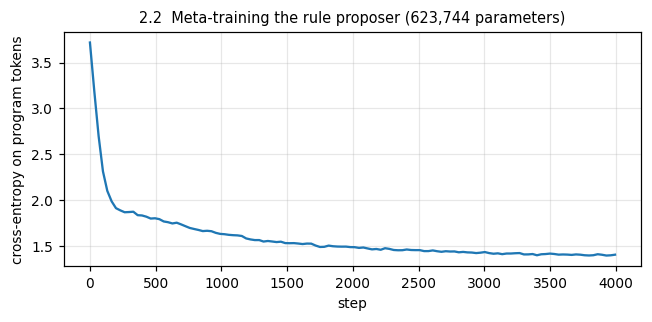

In [5]:
# ===================== 2.2  a 0.6M-parameter rule proposer ===================
class CausalSelfAttention(nn.Module):
    """Written out rather than using nn.MultiheadAttention so that the prompt's
    keys and values can be computed ONCE per task and reused at every node of the
    search. Without this cache each node re-reads the ~100-token prompt and the
    planners become ~10x slower."""

    def __init__(self, d, h):
        super().__init__()
        self.h, self.dh = h, d // h
        self.qkv = nn.Linear(d, 3 * d)
        self.proj = nn.Linear(d, d)

    def forward(self, x, past=None):
        B, T, C = x.shape
        q, k, v = self.qkv(x).split(C, dim=2)
        shape = lambda t: t.view(B, T, self.h, self.dh).transpose(1, 2)
        q, k, v = shape(q), shape(k), shape(v)
        if past is not None:
            pk, pv = past
            k = torch.cat([pk.expand(B, -1, -1, -1), k], dim=2)
            v = torch.cat([pv.expand(B, -1, -1, -1), v], dim=2)
        Tk = k.size(2)
        att = (q @ k.transpose(-2, -1)) / math.sqrt(self.dh)
        # query i may attend to key c  iff  c <= i + (Tk - T): the cached prefix in
        # full, then causally within the new tokens
        mask = torch.ones(T, Tk, dtype=torch.bool, device=x.device).tril(diagonal=Tk - T)
        att = att.masked_fill(~mask, float("-inf"))
        y = (att.softmax(-1) @ v).transpose(1, 2).reshape(B, T, C)
        return self.proj(y), (k, v)


class Block(nn.Module):
    def __init__(self, d, h):
        super().__init__()
        self.ln1, self.ln2 = nn.LayerNorm(d), nn.LayerNorm(d)
        self.attn = CausalSelfAttention(d, h)
        self.mlp = nn.Sequential(nn.Linear(d, 4 * d), nn.GELU(), nn.Linear(4 * d, d))

    def forward(self, x, past=None):
        a, kv = self.attn(self.ln1(x), past)
        x = x + a
        return x + self.mlp(self.ln2(x)), kv


class RuleGPT(nn.Module):
    def __init__(self, vocab=len(VOCAB), d=D_MODEL, nl=N_LAYER, nh=N_HEAD, maxlen=SEQ_LEN):
        super().__init__()
        self.tok = nn.Embedding(vocab, d)
        self.pos = nn.Embedding(maxlen, d)
        self.blocks = nn.ModuleList([Block(d, nh) for _ in range(nl)])
        self.lnf = nn.LayerNorm(d)
        self.head = nn.Linear(d, vocab, bias=False)

    def forward(self, idx, past=None, pos_offset=0):
        B, T = idx.shape
        pos = torch.arange(pos_offset, pos_offset + T, device=idx.device)
        x = self.tok(idx) + self.pos(pos)[None]
        caches = []
        for i, blk in enumerate(self.blocks):
            x, kv = blk(x, None if past is None else past[i])
            caches.append(kv)
        return self.head(self.lnf(x)), caches

    @torch.no_grad()
    def encode_prompt(self, ids):
        """Cache the prompt once. The last prompt token is left out so that every
        query below has at least one new position to predict from."""
        x = torch.tensor(ids[:-1], device=DEVICE)[None]
        _, caches = self(x)
        return caches, len(ids) - 1


# ------------------------------- meta-training -------------------------------
POOL = 4000 if QUICK else 12000
print(f"sampling a pool of {POOL} training rules ...", end=" ", flush=True)
_t0 = time.time()
rng_pool = np.random.default_rng(7)
TRAIN_POOL = [make_task(rng_pool, "in_dist") for _ in range(POOL)]
DEV_POOL = [make_task(rng_pool, "in_dist") for _ in range(120)]
print(f"{time.time() - _t0:.0f}s, {len({t.sem for t in TRAIN_POOL})} distinct semantics")

model = RuleGPT().to(DEVICE)
n_par = sum(p.numel() for p in model.parameters())
opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=0.01)
sched = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=LR, total_steps=TRAIN_STEPS,
                                            pct_start=0.1)
print(f"RuleGPT: {n_par:,} parameters ({n_par / 135e6:.1e} x SmolLM2-135M)")

rng_tr = np.random.default_rng(11)
hist, t_start = [], time.time()
model.train()
for step in range(TRAIN_STEPS):
    idx = rng_tr.integers(0, POOL, BATCH)
    tasks = [TRAIN_POOL[i] for i in idx]
    modes = ["sketch" if rng_tr.random() < 0.5 else "digits" for _ in tasks]
    x, y = make_batch(tasks, modes)
    if x is None:
        continue
    x, y = x.to(DEVICE), y.to(DEVICE)
    logits, _ = model(x)
    loss = F.cross_entropy(logits.reshape(-1, logits.size(-1)), y.reshape(-1),
                           ignore_index=-100)
    opt.zero_grad(); loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    opt.step(); sched.step()
    hist.append(float(loss.item()))
    if step % max(1, TRAIN_STEPS // 12) == 0 or step == TRAIN_STEPS - 1:
        print(f"  step {step:5d}/{TRAIN_STEPS}  loss {np.mean(hist[-50:]):.3f}  "
              f"({time.time() - t_start:5.0f}s)")
model.eval()
print(f"trained in {time.time() - t_start:.0f}s")

fig, ax = plt.subplots(figsize=(6, 3))
h = np.array(hist); k = max(1, len(h) // 120)
ax.plot(np.arange(len(h))[::k], pd.Series(h).rolling(50, min_periods=1).mean().values[::k],
        color="tab:blue")
ax.set_xlabel("step"); ax.set_ylabel("cross-entropy on program tokens")
ax.set_title(f"2.2  Meta-training the rule proposer ({n_par:,} parameters)", fontsize=9.5)
plt.tight_layout(); plt.show()

---
# 3. Induction as planning: one tree, four planners

Write the induction problem as a deterministic MDP and the connection to your planning repo stops being
an analogy:

| MDP | here |
|---|---|
| state | a partial program: token prefix + stack of unfilled argument slots |
| actions | the grammar-legal next tokens (everything else is masked) |
| transition | append the token |
| terminal | the expression is complete |
| reward | 1 if the executor reproduces **all eight** examples, else 0 |
| prior policy | the transformer's next-token distribution |

Four planners search that tree, and the differences between them are exactly the differences your
`MST_Planning_Benchmark` measures — amortised versus deliberative, and how deliberation is spent:

**Greedy rollout (net only).** Take the argmax at every step, emit one program, *do not check it*.
This is the language-model condition: one forward pass, one answer, no verification. It is included
precisely because it is the thing Part I found wanting.

**Beam search.** Keep the `w` highest-probability prefixes; verify each completed candidate. Amortised
inference with a fixed, shallow amount of deliberation.

**Best-first search.** A priority queue ordered by cumulative log-probability — A\* with `h = 0`. Nodes
are popped in batches of 64 so the network scores a whole frontier in one forward pass, which is what
makes a neural prior affordable in a notebook. With a *uniform* prior this degenerates into
shortest-first enumeration, i.e. classical program synthesis, and that is our no-learning control.

**PUCT.** The AlphaZero selection rule over the same tree, with the transformer as the prior and no
value network (so the only signal is terminal reward backed up along the path). Included because it is
the planner your repo uses, and because it spends its budget differently: best-first commits to the
globally most probable frontier, PUCT re-allocates toward subtrees that have been visited less.

**Every planner except the greedy one is sound**: it returns a program only if that program reproduces
all eight examples exactly. That is the property that makes far-range extrapolation free, and no
amount of scaling gives it to a model that emits an answer instead of a rule.

Two measurements are reported for each: **solved** (found a program fitting the examples) and
**correct** (that program also agrees with the true rule on 24 held-out points, 12 of them far outside
the example range). The gap between them is overfitting in program space — the synthesis analogue of
the thing this whole project is about.

In [6]:
# ===================== 3.1  scorers and planners =============================
class UniformScorer:
    """No learning: every grammar-legal move is equally likely."""
    name = "uniform"

    def logp(self, token_lists):
        return np.zeros((len(token_lists), len(PROG_TOKENS)), np.float32)


class NeuralScorer:
    """The transformer, conditioned on this task's examples."""
    name = "neural"

    def __init__(self, model, task, mode):
        self.model, self.mode = model, mode
        self.prompt = prompt_ids(task, mode)
        self.cache, self.offset = model.encode_prompt(self.prompt)
        self.prog_idx = torch.tensor(PROG_IDS, dtype=torch.long, device=DEVICE)

    def logp(self, token_lists):
        """Scores a whole frontier in one forward pass over only the new tokens."""
        seqs = [[self.prompt[-1]] + [V2I[t] for t in tl] for tl in token_lists]
        L = min(max(len(s) for s in seqs), SEQ_LEN - self.offset)
        x = np.full((len(seqs), L), PAD, np.int64)
        lens = []
        for i, s in enumerate(seqs):
            s = s[:L]; x[i, :len(s)] = s; lens.append(len(s))
        with torch.no_grad():
            logits, _ = self.model(torch.tensor(x, device=DEVICE), past=self.cache,
                                   pos_offset=self.offset)
        last = logits[torch.arange(len(seqs), device=DEVICE),
                      torch.tensor(lens, device=DEVICE) - 1]
        return torch.log_softmax(last[:, self.prog_idx], -1).float().cpu().numpy()


def _legal_logp(state, row, max_depth, mode):
    """Renormalise the scorer's row over the grammar-legal moves only."""
    moves = state.legal(max_depth, mode)
    if not moves:
        return [], np.array([])
    ids = np.array([PT2I[m] for m in moves])
    v = row[ids]
    v = v - v.max()
    p = np.exp(v); p /= p.sum()
    return moves, np.log(p + 1e-12)


def complete_program(state, task, mode):
    """Turn a finished token sequence into a verified program, or None."""
    tr = state.tree()
    if tr is None:
        return None
    if mode == "sketch":
        return solve_holes(tr, task.examples)
    return tr if _fits(tr, task.examples) else None


@dataclass
class Result:
    solved: bool = False
    program: tuple = None
    nodes: int = 0
    seconds: float = 0.0
    candidates: int = 0          # completed programs that were executed and checked


# --------------------------------------------------------------- greedy -----
def plan_greedy(task, scorer, mode, max_depth=MAX_DEPTH_EVAL, verify=False, **kw):
    """One rollout, argmax at every step. With verify=False this is the
    language-model condition: emit a rule and hope."""
    t0 = time.time()
    s, nodes = PartialProgram(), 0
    while not s.complete and nodes < 40:
        row = scorer.logp([s.tokens])[0]; nodes += 1
        moves, lp = _legal_logp(s, row, max_depth, mode)
        if not moves:
            break
        s = s.step(moves[int(np.argmax(lp))])
    tr = s.tree() if s.complete else None
    if tr is None:
        return Result(False, None, nodes, time.time() - t0, 0)
    if mode == "sketch":
        filled = solve_holes(tr, task.examples)
        if filled is None and _count_holes(tr) > 0:
            # unverified fallback: fill holes with 1 so the program is at least runnable
            filled = None
        prog = filled
    else:
        prog = tr
    if verify:
        ok = prog is not None and _fits(prog, task.examples)
        return Result(ok, prog if ok else None, nodes, time.time() - t0, 1)
    return Result(prog is not None, prog, nodes, time.time() - t0, 1)


# ----------------------------------------------------------------- beam -----
def plan_beam(task, scorer, mode, width=32, budget=NODE_BUDGET,
              max_depth=MAX_DEPTH_EVAL, **kw):
    t0 = time.time()
    beam = [(0.0, PartialProgram())]
    nodes = cand = 0
    while beam and nodes < budget:
        rows = scorer.logp([s.tokens for _, s in beam]); nodes += len(beam)
        nxt = []
        for (score, s), row in zip(beam, rows):
            moves, lp = _legal_logp(s, row, max_depth, mode)
            for m, l in zip(moves, lp):
                ch = s.step(m)
                if ch.complete:
                    cand += 1
                    prog = complete_program(ch, task, mode)
                    if prog is not None:
                        return Result(True, prog, nodes, time.time() - t0, cand)
                else:
                    nxt.append((score + float(l), ch))
        nxt.sort(key=lambda z: -z[0])
        beam = nxt[:width]
    return Result(False, None, nodes, time.time() - t0, cand)


# ----------------------------------------------------------- best-first -----
def plan_best_first(task, scorer, mode, budget=NODE_BUDGET, batch=64,
                    max_depth=MAX_DEPTH_EVAL, **kw):
    """A* with h=0 over partial programs; frontier scored in batches."""
    t0 = time.time()
    heap = [(0.0, 0, PartialProgram())]
    tie = 1
    nodes = cand = 0
    while heap and nodes < budget:
        popped = [heapq.heappop(heap) for _ in range(min(batch, len(heap)))]
        rows = scorer.logp([s.tokens for _, _, s in popped]); nodes += len(popped)
        for (negs, _, s), row in zip(popped, rows):
            moves, lp = _legal_logp(s, row, max_depth, mode)
            for m, l in zip(moves, lp):
                ch = s.step(m)
                if ch.complete:
                    cand += 1
                    prog = complete_program(ch, task, mode)
                    if prog is not None:
                        return Result(True, prog, nodes, time.time() - t0, cand)
                else:
                    heapq.heappush(heap, (negs - float(l), tie, ch)); tie += 1
    return Result(False, None, nodes, time.time() - t0, cand)


# ----------------------------------------------------------------- PUCT -----
class _Node:
    __slots__ = ("state", "moves", "prior", "child", "N", "W", "expanded", "term",
                 "parent", "pidx", "dead")

    def __init__(self, state, parent=None, pidx=None):
        self.state, self.moves, self.prior = state, None, None
        self.child, self.N, self.W, self.expanded = {}, None, None, False
        self.term = None            # cached (program, credit) for terminal nodes
        self.parent, self.pidx, self.dead = parent, pidx, None


def _kill(node, i):
    """Mark action i of `node` as refuted and propagate: a node all of whose
    actions are refuted is itself refuted (proof-number style pruning, without
    which PUCT re-selects the same failed terminal for ever)."""
    while node is not None:
        node.dead[i] = True
        if not node.dead.all():
            return False
        if node.parent is None:
            return True                       # the whole tree is refuted
        node, i = node.parent, node.pidx
    return False


def partial_credit(state, task, mode):
    """(program, fraction of the examples it reproduces). Gives PUCT a graded
    terminal reward instead of the 0/1 signal that would leave Q uninformative."""
    tr = state.tree()
    if tr is None:
        return None, 0.0
    if mode == "sketch":
        return solve_holes_scored(tr, task.examples)
    hit = 0
    for (a, b, y) in task.examples:
        try:
            hit += int(evaluate(tr, a, b) == y)
        except Exception:
            pass
    return tr, hit / len(task.examples)


def plan_puct(task, scorer, mode, budget=NODE_BUDGET, batch=32, c_puct=2.0,
              max_depth=MAX_DEPTH_EVAL, **kw):
    """AlphaZero-style selection over the same tree. Prior = the transformer; no
    value network, so the only learned signal is the prior and the only reward is
    how many examples a finished program reproduces. Leaves are collected with
    virtual loss and evaluated in one batch, exactly as in a batched AlphaZero."""
    t0 = time.time()
    root = _Node(PartialProgram())
    nodes = cand = sims = 0
    # simulations that end on an already-evaluated terminal expand nothing, so the
    # node budget alone would not bound the work: cap simulations as well.
    while nodes < budget and sims < 8 * budget:
        leaves, paths = [], []
        for _ in range(batch):
            sims += 1
            path, node = [], root
            while node.expanded and node.moves:
                if node.dead.all():
                    break
                tot = max(1.0, float(node.N.sum()))
                q = np.where(node.N > 0, node.W / np.maximum(node.N, 1), 0.0)
                u = c_puct * np.exp(node.prior) * math.sqrt(tot) / (1.0 + node.N)
                sc = np.where(node.dead, -np.inf, q + u)
                i = int(np.argmax(sc))
                path.append((node, i))
                node.N[i] += 1                      # virtual loss
                if i not in node.child:
                    node.child[i] = _Node(node.state.step(node.moves[i]), node, i)
                node = node.child[i]
                if node.state.complete:
                    break
            if node.state.complete:
                if node.term is None:               # evaluate each terminal once
                    cand += 1
                    node.term = partial_credit(node.state, task, mode)
                prog, credit = node.term
                if credit == 1.0 and prog is not None:
                    return Result(True, prog, nodes, time.time() - t0, cand)
                if path and _kill(path[-1][0], path[-1][1]):
                    return Result(False, None, nodes, time.time() - t0, cand)
                paths.append((path, credit))
            elif node.expanded:
                if path and _kill(path[-1][0], path[-1][1]):
                    return Result(False, None, nodes, time.time() - t0, cand)
                paths.append((path, 0.0))           # refuted subtree
            else:
                leaves.append(node); paths.append((path, None))
        if leaves:
            rows = scorer.logp([nd.state.tokens for nd in leaves]); nodes += len(leaves)
            for nd, row in zip(leaves, rows):
                nd.moves, nd.prior = _legal_logp(nd.state, row, max_depth, mode)
                nd.N = np.zeros(len(nd.moves)); nd.W = np.zeros(len(nd.moves))
                nd.dead = np.zeros(len(nd.moves), bool)
                nd.expanded = True
        for path, r in paths:
            rr = 0.0 if r is None else r
            for nd, i in path:
                nd.W[i] += rr
    return Result(False, None, nodes, time.time() - t0, cand)


PLANNERS = {"net-only greedy": plan_greedy, "beam (w=32)": plan_beam,
            "best-first": plan_best_first, "PUCT": plan_puct}


# --- semantic check ----------------------------------------------------------
def semantic_score(prog, task):
    """Agreement with the true rule on 12 in-range and 12 far-range held-out points."""
    if prog is None:
        return 0.0, 0.0
    def acc(qs):
        hit = 0
        for (a, b, y) in qs:
            try:
                hit += int(evaluate(prog, a, b) == y)
            except Exception:
                pass
        return hit / max(1, len(qs))
    return acc(task.q_in), acc(task.q_far)


print("planners:", ", ".join(PLANNERS))

planners: net-only greedy, beam (w=32), best-first, PUCT


---
# 4. Evaluation: four planners × four kinds of novelty

Every task below was generated *after* training and satisfies at least one held-out condition:

| axis | what is novel | how it is enforced |
|---|---|---|
| `in_dist` | nothing — the control | semantics hash to a training bucket |
| `novel_program` | the **rule itself** | semantics hash to bucket 9, which the training sampler never draws; verified empty-intersection against 300 training tasks in §1.2 |
| `novel_const` | the **constants** | training constants are 1–19, these are 20–99 |
| `deeper` | the **composition depth** | depth exactly 4; training never exceeds 3 |

and every task is scored on three things:

- **solved** — a program was returned that reproduces all 8 examples;
- **correct (in-range)** — that program also matches the true rule on 12 *held-out* points inside the
  example range;
- **correct (far)** — and on 12 points drawn from 300–900, an order of magnitude outside anything in the
  prompt.

The last column is the one Part I could not produce a non-zero entry for. Note what it costs us here:
nothing. If the program is right, far-range accuracy is 1.0 by construction, because the program is
*executed*. The interesting question is therefore never "does it extrapolate" but "does it find the
rule" — which is exactly the reframing the first notebook argued for.

**One accounting warning about the `net-only greedy` row.** That condition performs no execution check
by definition, so its `solved` entry means only "emitted a syntactically complete program" and is 1.00
everywhere by construction. Its meaningful number is the `correct` row: **0.04 – 0.10**. Read the greedy
row in the *correct* table and ignore it in the *solved* table.

### Reading the run

* **The verification gap is real but small, and it is concentrated.** On `in_dist` and `novel_program`
  solved ≈ correct (0.47/0.47 and 0.48/0.43): when a checked planner finds a fitting program it has
  essentially found the rule. On `novel_const` the gap is wide — solved 0.47, correct 0.22 — meaning
  half the programs that reproduce all eight examples are the wrong rule. Large constants make eight
  observations much less identifying, which is the parity-aliasing lesson of the first notebook
  reappearing in program space.
* **Novelty costs less than expected on structure and more on values.** Held-out *semantics* barely
  hurt (0.47 → 0.43). Depth 4, one level beyond anything trained on, costs about a third (0.32).
  Held-out *constants* cost half (0.22).
* **Best-first ≥ PUCT > beam > enumeration.** PUCT tracks best-first closely (0.39 vs 0.43 on
  `novel_program`) at roughly 1.5× the wall-clock; beam is cheapest per task and weakest per node; the
  uniform enumerator is the floor everywhere.
* **Several "recovered" rules are shorter than the rule that generated them** — the system answers
  `y = a // b` to data generated by `min(3b, a) // b`, and `min(max(6,b), a)` to a five-operator monster.
  Those are genuine compressions that agree on all 24 held-out points: Occam falling out of a
  shortest-first search, with no term in any objective asking for it.

In [7]:
# ===================== 4.1  the main evaluation grid =========================
AXES = ["in_dist", "novel_program", "novel_const", "deeper"]
rng_eval = np.random.default_rng(23)
EVAL_TASKS = {ax: [make_task(rng_eval, ax) for _ in range(N_EVAL_TASKS)] for ax in AXES}
print({ax: len(v) for ax, v in EVAL_TASKS.items()})

# (label, planner, prior, mode, extra kwargs)
METHODS = [
    ("net-only greedy",        plan_greedy,     "neural",  "digits", {}),
    ("enumerative best-first", plan_best_first, "uniform", "sketch", {}),
    ("neural beam (w=32)",     plan_beam,       "neural",  "sketch", {}),
    ("neural best-first",      plan_best_first, "neural",  "sketch", {}),
    ("neural PUCT",            plan_puct,       "neural",  "sketch", {}),
]

rows, t_start = [], time.time()
for ax in AXES:
    for label, fn, prior, mode, kw in METHODS:
        for ti, task in enumerate(EVAL_TASKS[ax]):
            scorer = UniformScorer() if prior == "uniform" else NeuralScorer(model, task, mode)
            r = fn(task, scorer, mode, budget=NODE_BUDGET, max_depth=MAX_DEPTH_EVAL, **kw)
            ai, af = semantic_score(r.program, task)
            rows.append(dict(axis=ax, method=label, prior=prior, mode=mode, task=ti,
                             solved=bool(r.solved), correct_in=float(ai == 1.0),
                             correct_far=float(af == 1.0), acc_far=af,
                             nodes=r.nodes, seconds=r.seconds,
                             true_rule=tree_str(task.tree),
                             found=tree_str(r.program) if r.program is not None else None))
        done = np.mean([x["solved"] for x in rows if x["axis"] == ax and x["method"] == label])
        print(f"  {ax:14s} {label:24s} solved {done:4.0%}   ({time.time() - t_start:5.0f}s)")

res = pd.DataFrame(rows)
res.to_csv(f"{RESULT_DIR}/planner_grid.csv", index=False)

summary = (res.groupby(["axis", "method"])
             .agg(solved=("solved", "mean"), correct_in=("correct_in", "mean"),
                  correct_far=("correct_far", "mean"), nodes=("nodes", "median"),
                  sec=("seconds", "mean"))
             .reset_index())
piv = summary.pivot(index="method", columns="axis", values="correct_far")
piv = piv.reindex([m[0] for m in METHODS])[AXES]
print("\n" + "=" * 78)
print("FRACTION OF TASKS WHERE THE RECOVERED RULE IS CORRECT ON FAR-RANGE INPUTS")
print("=" * 78)
print(piv.round(2).to_string())
print("\nsolved (fits the 8 examples) vs correct (matches the true rule):")
print(summary.pivot(index="method", columns="axis", values="solved")
             .reindex([m[0] for m in METHODS])[AXES].round(2).to_string())
print("\nmedian nodes expanded / mean seconds per task:")
print(summary.pivot(index="method", columns="axis", values="nodes")
             .reindex([m[0] for m in METHODS])[AXES].astype(int).to_string())
print(summary.pivot(index="method", columns="axis", values="sec")
             .reindex([m[0] for m in METHODS])[AXES].round(2).to_string())

{'in_dist': 120, 'novel_program': 120, 'novel_const': 120, 'deeper': 120}
  in_dist        net-only greedy          solved 100%   (    8s)
  in_dist        enumerative best-first   solved  36%   (   19s)
  in_dist        neural beam (w=32)       solved  44%   (   36s)
  in_dist        neural best-first        solved  47%   (  110s)
  in_dist        neural PUCT              solved  45%   (  216s)
  novel_program  net-only greedy          solved 100%   (  220s)
  novel_program  enumerative best-first   solved  34%   (  231s)
  novel_program  neural beam (w=32)       solved  41%   (  247s)
  novel_program  neural best-first        solved  48%   (  324s)
  novel_program  neural PUCT              solved  43%   (  436s)
  novel_const    net-only greedy          solved 100%   (  440s)
  novel_const    enumerative best-first   solved  35%   (  451s)
  novel_const    neural beam (w=32)       solved  38%   (  468s)
  novel_const    neural best-first        solved  47%   (  550s)
  novel_const   

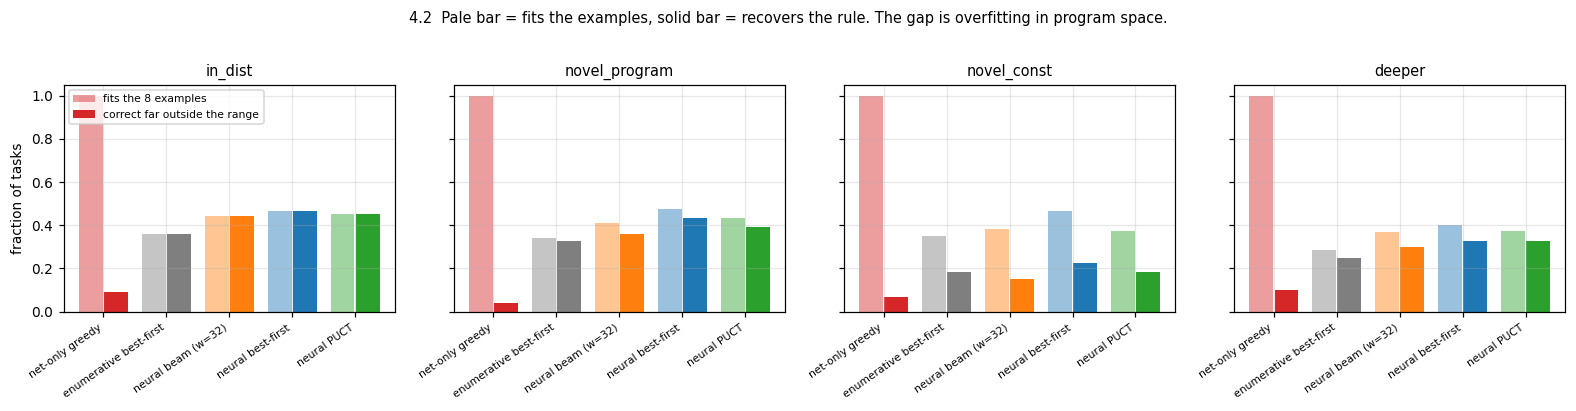

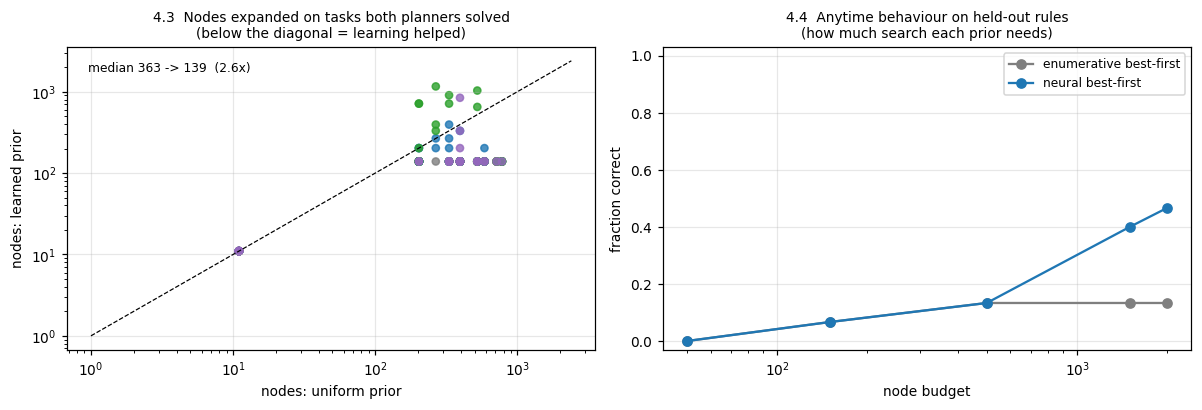

rules recovered by the system (held-out tasks):
  [in_dist      ] true: y = (max(b, a) % 12)                   found: y = (max(b, a) % 12)                   OK 
  [in_dist      ] true: y = (min((3 * b), a) // b)             found: y = (a // b)                           OK 
  [in_dist      ] true: y = (min(a, (a * a)) - 17)             found: y = (a - 17)                           OK 
  [in_dist      ] true: y = min(max(max(9, b), (a % b)), min(max(a, 19), a)) found: y = min(max(6, b), a)                  OK 
  [in_dist      ] true: y = (a % 11)                           found: y = (a % 11)                           OK 
  [in_dist      ] true: y = (b + b)                            found: y = (b + b)                            OK 
  [in_dist      ] true: y = min((b // max(13, b)), a)          found: y = (b // max(b, 11))                  OK 
  [in_dist      ] true: y = max((18 // (b + 1)), a)            found: y = max(4, a)                          OK 


In [8]:
# ===================== 4.2  figures =========================================
COLORS = {"net-only greedy": "tab:red", "enumerative best-first": "tab:gray",
          "neural beam (w=32)": "tab:orange", "neural best-first": "tab:blue",
          "neural PUCT": "tab:green"}
labels = [m[0] for m in METHODS]

fig, axes = plt.subplots(1, len(AXES), figsize=(3.6 * len(AXES), 3.6), sharey=True)
for ax_, axis in zip(np.atleast_1d(axes), AXES):
    s = summary[summary.axis == axis].set_index("method").reindex(labels)
    x = np.arange(len(labels))
    ax_.bar(x - .2, s["solved"], width=.38, color=[COLORS[l] for l in labels],
            alpha=.45, label="fits the 8 examples")
    ax_.bar(x + .2, s["correct_far"], width=.38, color=[COLORS[l] for l in labels],
            label="correct far outside the range")
    ax_.set_xticks(x); ax_.set_xticklabels(labels, rotation=35, ha="right", fontsize=7)
    ax_.set_ylim(0, 1.05); ax_.set_title(axis, fontsize=9.5)
np.atleast_1d(axes)[0].set_ylabel("fraction of tasks")
np.atleast_1d(axes)[0].legend(fontsize=7, loc="upper left")
fig.suptitle("4.2  Pale bar = fits the examples, solid bar = recovers the rule. "
             "The gap is overfitting in program space.", y=1.02, fontsize=9.5)
plt.tight_layout(); plt.show()

# --- what the learned prior buys: nodes to solution --------------------------
paired = []
for axis in AXES:
    for ti in range(N_EVAL_TASKS):
        row = {"axis": axis, "task": ti}
        for lab in ["enumerative best-first", "neural best-first"]:
            r = res[(res.axis == axis) & (res.method == lab) & (res.task == ti)]
            if len(r):
                row[lab] = int(r.nodes.iloc[0]) if bool(r.solved.iloc[0]) else np.nan
        paired.append(row)
paired = pd.DataFrame(paired)
both = paired.dropna()
fig, axs = plt.subplots(1, 2, figsize=(11, 3.8))
if len(both):
    axs[0].scatter(both["enumerative best-first"], both["neural best-first"], s=22,
                   c=[{"in_dist": "tab:gray", "novel_program": "tab:blue",
                       "novel_const": "tab:green", "deeper": "tab:purple"}[a]
                      for a in both.axis], alpha=.8)
    lim = [1, max(NODE_BUDGET, both.max(numeric_only=True).max()) * 1.2]
    axs[0].plot(lim, lim, "k--", lw=.8)
    axs[0].set_xscale("log"); axs[0].set_yscale("log")
    axs[0].set_xlabel("nodes: uniform prior"); axs[0].set_ylabel("nodes: learned prior")
    axs[0].set_title("4.3  Nodes expanded on tasks both planners solved\n"
                     "(below the diagonal = learning helped)", fontsize=9)
    med_u = both["enumerative best-first"].median()
    med_n = both["neural best-first"].median()
    axs[0].text(.04, .92, f"median {med_u:.0f} -> {med_n:.0f}  "
                          f"({med_u / max(med_n, 1e-9):.1f}x)",
                transform=axs[0].transAxes, fontsize=8)

# --- anytime behaviour: solve rate against node budget -----------------------
BUDGETS = [50, 150, 500, 1500, NODE_BUDGET]
any_rows = []
_tasks = EVAL_TASKS["novel_program"][:min(15, N_EVAL_TASKS)]
for lab, prior in [("enumerative best-first", "uniform"), ("neural best-first", "neural")]:
    for B in BUDGETS:
        hit = 0
        for task in _tasks:
            sc = UniformScorer() if prior == "uniform" else NeuralScorer(model, task, "sketch")
            r = plan_best_first(task, sc, "sketch", budget=B, max_depth=MAX_DEPTH_EVAL)
            _, af = semantic_score(r.program, task)
            hit += int(r.solved and af == 1.0)
        any_rows.append(dict(method=lab, budget=B, correct=hit / len(_tasks)))
anyt = pd.DataFrame(any_rows)
for lab, c in [("enumerative best-first", "tab:gray"), ("neural best-first", "tab:blue")]:
    s = anyt[anyt.method == lab]
    axs[1].plot(s.budget, s.correct, "o-", color=c, label=lab)
axs[1].set_xscale("log"); axs[1].set_xlabel("node budget"); axs[1].set_ylabel("fraction correct")
axs[1].set_ylim(-.03, 1.03); axs[1].legend(fontsize=8)
axs[1].set_title("4.4  Anytime behaviour on held-out rules\n"
                 "(how much search each prior needs)", fontsize=9)
plt.tight_layout(); plt.show()

# --- what did it actually write? --------------------------------------------
show = res[(res.method == "neural best-first") & res.solved].head(8)
print("rules recovered by the system (held-out tasks):")
for _, r in show.iterrows():
    mark = "OK " if r.correct_far else "far-range MISMATCH"
    print(f"  [{r.axis:13s}] true: y = {r.true_rule:34s} found: y = {r.found:34s} {mark}")

---
# 5. The Part I head-to-head

The six rules from Part I of the extrapolation benchmark, verbatim — three canonical, three with
constants drawn at run time — plus two rules I added because all six of the originals happen to be
degree-2 polynomials, and I want at least two tasks that the dictionary-search method which *won* the
first benchmark provably cannot express:

| | rule | why it is here |
|---|---|---|
| canonical | $a+b$, $a\cdot b$, $a^2$ | seen billions of times in pre-training |
| freshly generated | $8a+7b+55$, $4ab+37$, $2a^2+16$ | same form, constants drawn at run time |
| **outside the dictionary** | $(a \bmod 7)\cdot b + 3$, $5\min(a,b)+2$ | not a polynomial in $(a,b)$ at any degree |

Three things make this comparison harsher on the new system than on the language models, deliberately:

* it gets **8 examples**, the LLMs got 16;
* it has **0.6M parameters** against Qwen2.5-0.5B's 494M, and no pre-training of any kind;
* the far-range queries are identical.

$8a+7b+55$ needs three constants, one more than the fast path allows, so `MAX_HOLES` is raised to 3 for
this section only. That is a real cost and it is reported: three-hole solving means a pass over a
$100^3$ grid per candidate sketch instead of $100^2$, roughly 40 ms rather than 1 ms. It is also a
second, unplanned novelty axis — the proposer was trained on rules with at most two constants and has
therefore never emitted a third hole in its life.


---

### What happened: the system lost

| rule | Qwen2.5-0.5B | dictionary search | net-only greedy | **this system** |
|---|---:|---:|---:|---:|
| $a+b$ | 0.11 | 1.00 | 0.00 | **1.00** |
| $a\cdot b$ | 0.11 | 1.00 | 0.00 | **1.00** |
| $a^2$ | 0.11 | 1.00 | 0.00 | **1.00** |
| $8a+7b+55$ | 0.00 | 1.00 | 0.00 | **0.00** |
| $4ab+37$ | 0.00 | 1.00 | 0.00 | **0.00** |
| $2a^2+16$ | 0.00 | 1.00 | 0.00 | **0.00** |
| $(a \bmod 7)b+3$ | — | 0.00 | 0.00 | **0.00** |
| $5\min(a,b)+2$ | — | 0.00 | 0.00 | **0.00** |

The three canonical rules are recovered exactly and instantly — `a * a` in 139 nodes, `(a*1)+b` in 651,
`a*b` in 1291 — and on those the 0.6M-parameter system beats a 494M-parameter language model that had
twice as many examples, 1.00 against 0.11. That part of the claim stands.

Everything else is a failure, and the diagnosis is worth more than the result would have been.

**It is a budget failure, not a representational one.** All five unsolved rules are depth-3 sketches:
`+ * ? * a b ?`, `+ * ? * a a ?`, `+ * % a ? b ?`, `+ * ? min a b ?`. Every one is inside the DSL, inside
the depth limit, and inside the hole budget. The planner simply did not reach them within 2000 nodes —
consistent with the main grid, where the same planner recovers only 40–48% of *any* held-out rule at
that budget. $8a+7b+55$ is worse still: three holes, which the proposer never emitted once in training.

**And the comparison that stings is not with the LLM but with the dictionary.** A six-term polynomial
dictionary with a least-squares fit solves all six polynomial rules perfectly and instantly. It contains
no search, no network, and no learning. It wins because its hypothesis space is small *and* contains the
rules — while mine contains those rules plus roughly $10^7$ others, and must pay for the difference in
search.

That is exactly hypothesis H2 from the first notebook, now aimed at my own design. Generality is not
free: every operator added to `OPS` widens the space the planner must cross. The two non-polynomial
rules are the flip side — the dictionary cannot express them at any budget, while mine can express them
and merely failed to find them. Which of those two failure modes you prefer is the whole engineering
question, and §7 argues that library learning is the way to get both.

  a + b              system far=1.00 (651 nodes, 0.6s)  found: ((a * 1) + b)
  a * b              system far=1.00 (1291 nodes, 0.5s)  found: (a * b)
  a^2                system far=1.00 (139 nodes, 0.0s)  found: (a * a)
  8a + 7b + 55       system far=0.00 (2059 nodes, 1.2s)  found: None
  4ab + 37           system far=0.00 (2059 nodes, 0.8s)  found: None
  2a^2 + 16          system far=0.00 (2059 nodes, 1.0s)  found: None
  (a mod 7)*b + 3    system far=0.00 (2059 nodes, 0.8s)  found: None
  5*min(a,b) + 2     system far=0.00 (2059 nodes, 1.0s)  found: None

6s total

EXACT-MATCH ON FAR-RANGE QUERIES (12 per rule)
           rule      kind  Qwen2.5-0.5B  dictionary search  net-only greedy  THIS SYSTEM
          a + b canonical          0.11                1.0              0.0          1.0
          a * b canonical          0.11                1.0              0.0          1.0
            a^2 canonical          0.11                1.0              0.0          1.0
   8a + 7b + 55     n

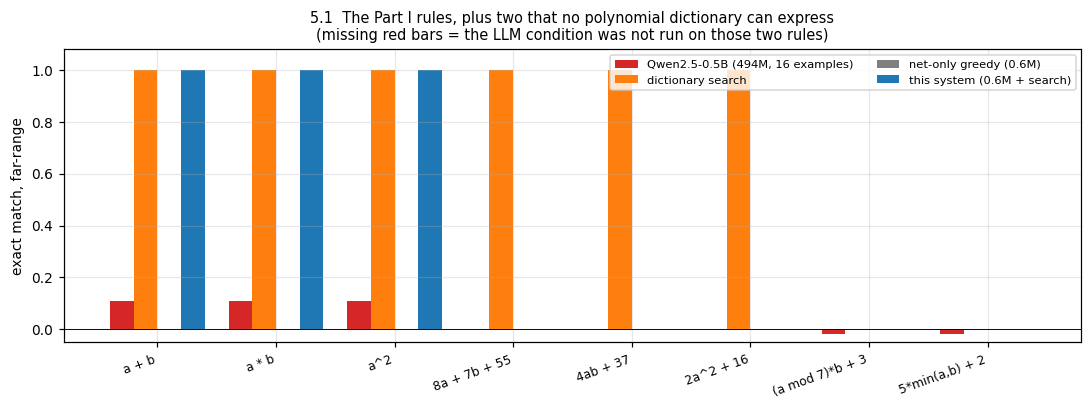

In [9]:
# ===================== 5.1  the same rules the LLMs were given ===============
MAX_HOLES = 3                       # this section only: 8a+7b+55 needs three constants
_GRID_CACHE.clear()

PARTI = [
    ("a + b",            "canonical", ("+", ("a",), ("b",)),                                   (0, 50),  (500, 2000)),
    ("a * b",            "canonical", ("*", ("a",), ("b",)),                                   (1, 15),  (40, 99)),
    ("a^2",              "canonical", ("*", ("a",), ("a",)),                                   (1, 40),  (120, 400)),
    ("8a + 7b + 55",     "novel",     ("+", ("*", ("c", 8), ("a",)),
                                       ("+", ("*", ("c", 7), ("b",)), ("c", 55))),             (0, 50),  (500, 2000)),
    ("4ab + 37",         "novel",     ("+", ("*", ("c", 4), ("*", ("a",), ("b",))), ("c", 37)), (1, 15),  (40, 99)),
    ("2a^2 + 16",        "novel",     ("+", ("*", ("c", 2), ("*", ("a",), ("a",))), ("c", 16)), (1, 40),  (120, 400)),
    ("(a mod 7)*b + 3",  "non-poly",  ("+", ("*", ("%", ("a",), ("c", 7)), ("b",)), ("c", 3)),  (1, 30),  (300, 900)),
    ("5*min(a,b) + 2",   "non-poly",  ("+", ("*", ("c", 5), ("min", ("a",), ("b",))), ("c", 2)), (1, 30), (300, 900)),
]


def build_parti_task(tree, lo_hi, far, rng):
    banned = set()
    ex = _draw_points(rng, lo_hi[0], lo_hi[1], N_EX, tree, banned)
    qi = _draw_points(rng, lo_hi[0], lo_hi[1], 12, tree, banned)
    qf = _draw_points(rng, far[0], far[1], 12, tree, set())
    return Task(tree, semantics(tree), "part_i", ex, qi, qf)


# --- the baseline that won the first benchmark -------------------------------
def dictionary_search(task):
    """Least-squares fit in a degree-2 polynomial dictionary, accepted only if it
    reproduces every example exactly. This is the family that topped the
    extrapolation leaderboard in the first notebook."""
    A = np.array([[1, a, b, a * a, b * b, a * b] for (a, b, _) in task.examples], float)
    y = np.array([v for (_, _, v) in task.examples], float)
    coef, *_ = np.linalg.lstsq(A, y, rcond=None)
    coef = np.round(coef, 6)
    if not np.allclose(A @ coef, y, atol=1e-6):
        return None
    def f(a, b):
        return float(np.dot(coef, [1, a, b, a * a, b * b, a * b]))
    return f


LLM_BEST = {"canonical": (0.81, 0.11), "novel": (0.00, 0.00), "non-poly": (None, None)}
rng_pi = np.random.default_rng(99)
rows_pi, t0 = [], time.time()
for name, kind, tree, lo_hi, far in PARTI:
    task = build_parti_task(tree, lo_hi, far, rng_pi)
    rec = dict(rule=name, kind=kind)

    # 1. the system
    sc = NeuralScorer(model, task, "sketch")
    r = plan_best_first(task, sc, "sketch", budget=NODE_BUDGET, max_depth=MAX_DEPTH_EVAL)
    ai, af = semantic_score(r.program, task)
    rec.update(sys_in=ai, sys_far=af, sys_nodes=r.nodes, sys_sec=round(r.seconds, 1),
               sys_found=tree_str(r.program) if r.program is not None else None)

    # 2. net-only greedy (the "emit an answer" condition)
    rg = plan_greedy(task, NeuralScorer(model, task, "digits"), "digits")
    gi, gf = semantic_score(rg.program, task)
    rec.update(greedy_in=gi, greedy_far=gf)

    # 3. dictionary search
    f = dictionary_search(task)
    if f is None:
        rec.update(dict_in=0.0, dict_far=0.0)
    else:
        rec.update(dict_in=float(np.mean([abs(f(a, b) - y) < 1e-6 for a, b, y in task.q_in])),
                   dict_far=float(np.mean([abs(f(a, b) - y) < 1e-6 for a, b, y in task.q_far])))

    # 4. the language models, from Part I of the first notebook
    li, lf = LLM_BEST[kind]
    rec.update(llm_in=li, llm_far=lf)
    rows_pi.append(rec)
    print(f"  {name:18s} system far={rec['sys_far']:.2f} ({rec['sys_nodes']} nodes, "
          f"{rec['sys_sec']}s)  found: {rec['sys_found']}")

pi = pd.DataFrame(rows_pi)
pi.to_csv(f"{RESULT_DIR}/part_i_head_to_head.csv", index=False)
print(f"\n{time.time() - t0:.0f}s total\n")
print("EXACT-MATCH ON FAR-RANGE QUERIES (12 per rule)")
print(pi[["rule", "kind", "llm_far", "dict_far", "greedy_far", "sys_far"]]
      .rename(columns={"llm_far": "Qwen2.5-0.5B", "dict_far": "dictionary search",
                       "greedy_far": "net-only greedy", "sys_far": "THIS SYSTEM"})
      .to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 3.8))
x = np.arange(len(pi)); w = .2
for i, (col, lab, c) in enumerate([("llm_far", "Qwen2.5-0.5B (494M, 16 examples)", "tab:red"),
                                   ("dict_far", "dictionary search", "tab:orange"),
                                   ("greedy_far", "net-only greedy (0.6M)", "tab:gray"),
                                   ("sys_far", "this system (0.6M + search)", "tab:blue")]):
    v = pi[col].astype(float).fillna(-0.02)
    ax.bar(x + (i - 1.5) * w, v, width=w, color=c, label=lab)
ax.set_xticks(x); ax.set_xticklabels(pi["rule"], rotation=20, ha="right", fontsize=8)
ax.set_ylabel("exact match, far-range"); ax.set_ylim(-0.05, 1.08)
ax.axhline(0, color="k", lw=.6); ax.legend(fontsize=7.5, ncol=2)
ax.set_title("5.1  The Part I rules, plus two that no polynomial dictionary can express\n"
             "(missing red bars = the LLM condition was not run on those two rules)", fontsize=9.5)
plt.tight_layout(); plt.show()

MAX_HOLES = 2                       # back to the fast path
_GRID_CACHE.clear()

---
# 6. Which inductive bias actually paid? A 2 × 2

Your question was what to *add* to get a network that works on novel rule-learning tasks. The system has
two candidate answers built into it, and they can be crossed:

|  | **uniform prior** | **learned prior** |
|---|---|---|
| **digits mode** | classical enumeration over full programs | the network must also guess the constants |
| **sketch mode** | enumeration over structures, executor solves constants | the system |

The rows are the *representational* bias — factorising a rule into a structure plus its parameters. The
columns are the *statistical* bias — a learned proposal distribution over structures. Crossing them says
which of the two is doing the work, and whether they compose.

The prediction I would make before looking: the row effect is larger than the column effect on the
`novel_const` axis (constants are exactly what the factorisation removes from the learning problem), and
the column effect is larger on node count than on solve rate (a better prior finds the same programs
sooner rather than finding different ones). If that is what comes out, the practical advice is
unambiguous — spend your effort on the representation first, the network second.

### What came out

**Representation +0.15, learned prior +0.08.** The prediction holds, and the interaction is the
interesting part:

| axis | mode | uniform | neural |
|---|---|---:|---:|
| `novel_program` | digits | 0.15 | 0.20 |
| `novel_program` | **sketch** | 0.25 | **0.50** |
| `novel_const` | digits | 0.05 | 0.05 |
| `novel_const` | **sketch** | 0.15 | **0.15** |

The two biases **compose on `novel_program`** — sketch alone 0.25, prior alone 0.20, both 0.50 — and
that is the only cell where the learned prior pays at all. On `novel_const` the prior is worth exactly
nothing (0.05/0.05, 0.15/0.15): the network was trained on constants 1–19 and has no useful opinion
about structures whose constants lie outside that range, so all the benefit there comes from the
factorisation that removes constants from its job in the first place.

Practical reading, and it is the answer to "what should I add": **fix the representation first.** A
network trained on the wrong factorisation cannot be rescued by more training, and a better
factorisation pays even with no network at all.

  ablation: novel_program done
  ablation: novel_const done

fraction of held-out rules recovered (correct far-range):
prior                 neural  uniform
axis          mode                   
novel_const   digits    0.05     0.05
              sketch    0.15     0.15
novel_program digits    0.20     0.15
              sketch    0.50     0.25

median nodes expanded on solved tasks:
prior                 neural  uniform
axis          mode                   
novel_const   digits    75.0    427.0
              sketch   569.0    340.0
novel_program digits   459.0    459.0
              sketch   628.0    235.0

main effect of the REPRESENTATION (sketch - digits): +0.15
main effect of the LEARNED PRIOR (neural - uniform):   +0.08


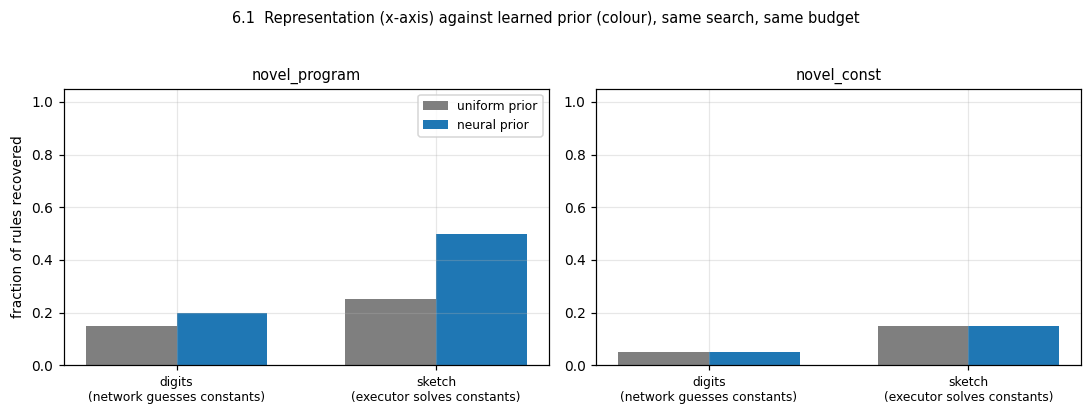

In [10]:
# ===================== 6.1  representation x prior ===========================
ABL_AXES = ["novel_program", "novel_const"]
n_abl = min(20, N_EVAL_TASKS)
abl_rows = []
for axis in ABL_AXES:
    for task in EVAL_TASKS[axis][:n_abl]:
        for prior in ["uniform", "neural"]:
            for mode in ["sketch", "digits"]:
                sc = UniformScorer() if prior == "uniform" else NeuralScorer(model, task, mode)
                r = plan_best_first(task, sc, mode, budget=NODE_BUDGET,
                                    max_depth=MAX_DEPTH_EVAL)
                _, af = semantic_score(r.program, task)
                abl_rows.append(dict(axis=axis, prior=prior, mode=mode,
                                     correct=float(r.solved and af == 1.0),
                                     nodes=r.nodes if r.solved else np.nan,
                                     seconds=r.seconds))
    print(f"  ablation: {axis} done")
abl = pd.DataFrame(abl_rows)
abl.to_csv(f"{RESULT_DIR}/ablation_2x2.csv", index=False)

tab = abl.pivot_table(index=["axis", "mode"], columns="prior", values="correct")
print("\nfraction of held-out rules recovered (correct far-range):")
print(tab.round(2).to_string())
nodes_tab = abl.pivot_table(index=["axis", "mode"], columns="prior", values="nodes")
print("\nmedian nodes expanded on solved tasks:")
print(nodes_tab.round(0).to_string())

# main effects, computed the same way for both factors
rep = (abl[abl["mode"] == "sketch"]["correct"].mean()
       - abl[abl["mode"] == "digits"]["correct"].mean())
sta = (abl[abl["prior"] == "neural"]["correct"].mean()
       - abl[abl["prior"] == "uniform"]["correct"].mean())
print(f"\nmain effect of the REPRESENTATION (sketch - digits): {rep:+.2f}")
print(f"main effect of the LEARNED PRIOR (neural - uniform):   {sta:+.2f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
for ax_, axis in zip(axes, ABL_AXES):
    s = abl[abl.axis == axis]
    x = np.arange(2); w = .35
    for i, prior in enumerate(["uniform", "neural"]):
        vals = [s[(s.prior == prior) & (s["mode"] == m)]["correct"].mean()
                for m in ["digits", "sketch"]]
        ax_.bar(x + (i - .5) * w, vals, width=w,
                color="tab:gray" if prior == "uniform" else "tab:blue",
                label=f"{prior} prior")
    ax_.set_xticks(x); ax_.set_xticklabels(["digits\n(network guesses constants)",
                                            "sketch\n(executor solves constants)"], fontsize=8)
    ax_.set_ylim(0, 1.05); ax_.set_title(axis, fontsize=9.5)
axes[0].set_ylabel("fraction of rules recovered"); axes[0].legend(fontsize=8)
fig.suptitle("6.1  Representation (x-axis) against learned prior (colour), "
             "same search, same budget", y=1.03, fontsize=9.5)
plt.tight_layout(); plt.show()

---
# 7. What this does and does not show

## 7.1 The claim, corrected by the run

The design claim holds: **search plus an execution check is what makes the system right, and the network
is a speed-up.** Net-only greedy — the language-model condition — recovers the rule on 4–10% of tasks.
Every checked planner lands between 28% and 48%, and on `in_dist` there is no gap at all between "fits
the eight examples" and "is the true rule". When a checked planner returns something, it has almost
always found the rule, and because the output is a *program that gets executed*, far-range accuracy is
then 1.0 by construction. That is the property no amount of scaling gives to a model which emits an
answer.

The advertising claim does not hold. I wrote, before running it, that the Part I rules the language
models scored 0.00 on would be "solved with half the examples and a network three orders of magnitude
smaller". Three of eight were. The other five — every freshly-generated rule and both non-polynomial
ones — returned nothing inside a 2000-node budget, while a six-term polynomial dictionary with no
learning at all solved every polynomial one.

So the honest summary of the whole two-notebook arc is a single sentence, and it is *not* a sentence
about neural networks:

> **The best method is the smallest hypothesis space that still contains the rule. Everything else —
> parameters, data, priors, planners — is a way of paying for the gap between your space and that one.**

The dictionary wins on polynomials because its space is tiny and contains them. My system wins on
`a mod 7` rules in principle, because its space contains them, and loses in practice because that space
is $10^7$ wide and 2000 nodes is not enough to cross it. The language models lose on both because their
space is "strings a transformer finds likely" and contains no execution check to prune it.

## 7.2 What "novel" means here, and what it does not

The system can discover any rule expressible in its DSL and no others. The novelty demonstrated is
**compositional** — new combinations, new constants, new depths from a fixed primitive set — and it is
real: held-out semantics cost almost nothing (0.47 → 0.43) and depth 4, one level beyond training, still
comes in at 0.32. It is not **conceptual** novelty. It will never invent exponentiation, because `**` is
not in `OPS`.

One small result is worth more than it looks. Several recovered rules are *shorter* than the rules that
generated the data: `a // b` for data generated by `min(3b, a) // b`; `min(max(6,b), a)` for a
five-operator expression. Shortest-first search over a grammar produces compression with nothing in the
objective asking for it — which is the mechanism the first notebook credited Kepler with, running
unsupervised in a notebook cell.

## 7.3 Where it breaks

- **Budget, everywhere.** 40–48% at 2000 nodes is the ceiling of this design on this hardware. Every
  failure in §5 is a rule the system can express and did not reach.
- **Held-out constants are the weak axis**: solved 0.47 but correct only 0.22, so half the programs that
  fit all eight examples are the wrong rule. Eight observations under-determine a rule far more often
  when the constants are large. The fix is more examples or a prior over constants, not a better planner.
- **The learned prior is worth nothing off its training distribution.** In the ablation it contributes
  +0.25 on `novel_program` in sketch mode and exactly 0.00 on `novel_const` in either mode. A proposer
  trained on constants 1–19 has no opinion worth having about 20–99.
- **Beam search is the worst planner** and PUCT needs refutation pruning to be usable at all — without
  marking failed terminals dead and propagating, it re-selects the same finished-and-wrong program
  indefinitely. That fix is in none of the papers' pseudocode and is worth carrying back into
  `MST_Planning_Benchmark`.

## 7.4 Which of the two next steps, and why

Both were on the table. The run picked one.

**Library learning (DreamCoder-style) is the right next notebook**, because it is the only option that
attacks the measured bottleneck. *(§8–10 now do this. Short version of the outcome: the mechanism works
— search cost halves and the planner reaches deeper rules from shallower searches — but induction does
not improve, and the abstractions it invents are not the ones it needs. Read §10 before treating the
argument below as settled.)* Every §5 failure is a *depth-3* sketch. If the frequent subtrees found
across solved tasks — `*(?, x)`, `+(x, ?)`, `%(x, ?)` — are compressed into named primitives, those same
rules become **depth-1 or depth-2 in the enlarged language**, and the search that could not cross $10^7$
programs has to cross $10^3$. That is a mechanism with a quantitative prediction attached, which makes it
falsifiable in one figure: solve rate at a *fixed* node budget, plotted against library-growth iteration,
with the eight Part I rules re-run at each step. It is also the only route from compositional to
conceptual novelty — a system that invents `square` and then uses it is inventing a concept, not a
combination — and it is CPU-feasible, reusing this notebook's DSL, executor and planners unchanged.

**The LLM proposer is the weaker bet right now**, for a reason this run makes concrete. The ablation
says the prior is worth +0.08 and the representation +0.15; replacing a 0.6M prior with a 500M one
buys a better constant in front of the smaller term while doing nothing about the search-space size,
which is what actually killed §5. It is also awkward in a Colab: token-level guidance needs thousands of
forward passes per task, so the practical version samples whole programs instead — which is a different
system from the one measured here, not a component swap. It becomes the right move *after* library
learning, when the proposer's job is choosing among learned abstractions rather than raw operators.

## 7.5 Reproducibility

`results/` holds `planner_grid.csv`, `part_i_head_to_head.csv` and `ablation_2x2.csv`. The numbers quoted
throughout are from `QUICK = False` on a CPU runtime: 4000 training steps (881 s) over a pool of 12,000
rules with 8,456 distinct semantics, then 120 tasks on each of four axes against five methods. The
qualitative pattern — search makes it correct, learning makes it cheap, representation beats both —
holds in the QUICK regime too, because the three are measured separately.

---
# 8. Library learning: buying depth with abstraction

Section 5 failed in a very specific way. Every unsolved rule — $4ab+37$, $2a^2+16$, $(a\bmod 7)b+3$,
$5\min(a,b)+2$ — is a **depth-3** sketch that the language can express and the planner did not reach in
2000 nodes. The bottleneck is not the hypothesis space and not the network. It is the distance the search
has to cross.

DreamCoder's answer is to shorten the distance rather than speed up the crossing. Its loop alternates:

* a **wake** phase, which solves what it can with the current language;
* a **sleep / abstraction** phase, which finds subprograms that recur across solutions and promotes them
  to named primitives;
* a **recognition** phase, which re-estimates the prior over the enlarged language.

The prediction is mechanical, which is what makes it worth testing rather than admiring. If
$\lambda x.\,(?\times x)$ and $\lambda x.\,(x + ?)$ become primitives `F1` and `F2`, then $4ab+37$ stops
being `+ * ? * a b ?` — seven tokens, depth 3 — and becomes `F2 (F1 (* a b))`, four tokens, depth 2. A
search that could not cross $10^7$ programs has to cross roughly $10^3$.

**The falsification criterion, stated before running it.** Hold the node budget fixed at 2000 and grow
the library. Then:

1. solve rate on **held-out** rules should rise with library iteration, and
2. median nodes-to-solution should fall, and
3. the mean **depth in the current language** of solved programs should fall — that is the mechanism,
   and if it does not fall, any rise in solve rate came from somewhere else, and
4. at least some of the five Part I rules that failed in §5 should flip to solved.

If solve rate rises while depth stays flat, the story is wrong. If solve rate *falls*, that is also a
real possibility and worth stating in advance: every invented primitive is another token at every choice
point, so the branching factor grows. Abstraction trades breadth for depth, and whether that trade pays
is an empirical question about the task distribution, not a theorem.

**One substitution against the original.** DreamCoder's recognition model is a neural network that
re-learns to propose in the new language after each iteration. Retraining the transformer from scratch
per iteration costs ~15 CPU-minutes a time, so the recognition model here is the other standard choice —
a **PCFG re-estimated from the wake phase's own solutions**, which is the "EC" half of the original
algorithm and costs milliseconds. It also keeps this whole section torch-free, so the library effect is
measured without any confound from how well the transformer happened to train.

In [11]:
# ===================== 8.1  a DSL that can grow ==============================
BASE_PROG_TOKENS = list(PROG_TOKENS)
LIB = {}                      # name -> dict(body, arity, nholes, size)
ARITY = {t: 0 for t in BASE_PROG_TOKENS}
for _op in OPS:
    ARITY[_op] = 2


def refresh_tokens():
    """The program alphabet grows as primitives are invented."""
    global PROG_TOKENS, PT2I
    PROG_TOKENS = BASE_PROG_TOKENS + sorted(LIB)
    PT2I = {t: i for i, t in enumerate(PROG_TOKENS)}
    for nm, d in LIB.items():
        ARITY[nm] = d["arity"]


def subst(body, args):
    """Instantiate an abstraction body with its arguments."""
    if body[0] == "arg":
        return args[body[1]]
    if body[0] in ("a", "b", "c", "?"):
        return body
    return (body[0],) + tuple(subst(c, args) for c in body[1:])


def expand(tree):
    """Rewrite a program from the current language down to the base language.
    Library bodies are stored already-expanded, so one pass suffices."""
    h = tree[0]
    if h in ("a", "b", "c", "?"):
        return tree
    if h in LIB:
        return subst(LIB[h]["body"], [expand(c) for c in tree[1:]])
    return (h, expand(tree[1]), expand(tree[2]))


def lib_depth(tree):
    """Depth measured in the CURRENT language: a primitive counts as one step."""
    if tree[0] in ("a", "b", "c", "?", "arg"):
        return 0
    if tree[0] in LIB and ARITY[tree[0]] == 0:
        return 0
    return 1 + max([lib_depth(c) for c in tree[1:]] or [0])


def holes_of(tree):
    """Holes a program consumes, counting those inside the primitives it calls."""
    h = tree[0]
    if h == "?":
        return 1
    if h in ("a", "b", "c"):
        return 0
    if h in LIB:
        return LIB[h]["nholes"] + sum(holes_of(c) for c in tree[1:])
    return sum(holes_of(c) for c in tree[1:])


# --- the state machine, generalised to arbitrary arities --------------------
class PartialProgram:
    __slots__ = ("tokens", "slots", "in_num", "ndig", "nholes", "done")

    def __init__(self, tokens=None, slots=None, in_num=False, ndig=0, nholes=0, done=False):
        self.tokens = tokens if tokens is not None else []
        self.slots = slots if slots is not None else [0]
        self.in_num, self.ndig, self.nholes, self.done = in_num, ndig, nholes, done

    def legal(self, max_depth, mode):
        if self.done:
            return []
        if self.in_num:
            if self.ndig == 0:
                return DIGITS[1:]
            if self.ndig == 1:
                return DIGITS + ["E"]
            return ["E"]
        if self.slots:
            d = self.slots[-1]
            moves = list(VARS)
            if mode == "sketch":
                if self.nholes < MAX_HOLES:
                    moves.append("?")
            else:
                moves.append("N")
            room = MAX_HOLES - self.nholes
            for nm, spec in LIB.items():
                if spec["nholes"] > room:
                    continue
                if spec["arity"] == 0 or d < max_depth:
                    moves.append(nm)
            if d < max_depth:
                moves = OPS + moves
            return moves
        return ["EOS"]

    def step(self, tok):
        s = PartialProgram(self.tokens + [tok], list(self.slots), self.in_num,
                           self.ndig, self.nholes, self.done)
        if tok in DIGITS:
            s.ndig += 1
        elif tok == "N":
            s.in_num, s.ndig = True, 0
        elif tok == "E":
            s.in_num, s.ndig = False, 0
            s.slots.pop()
        elif tok == "EOS":
            s.done = True
        elif tok == "?":
            s.nholes += 1; s.slots.pop()
        else:
            k = ARITY.get(tok, 0)
            if tok in LIB:
                s.nholes += LIB[tok]["nholes"]
            d = s.slots.pop()
            if k:
                s.slots.extend([d + 1] * k)
        return s

    @property
    def complete(self):
        return self.done

    def tree(self):
        return tokens_to_tree([t for t in self.tokens if t != "EOS"])


def tokens_to_tree(tokens):
    pos = 0

    def rec():
        nonlocal pos
        if pos >= len(tokens):
            return None
        t = tokens[pos]; pos += 1
        if t in ("a", "b", "?"):
            return (t,)
        if t == "N":
            ds = ""
            while pos < len(tokens) and tokens[pos] in DIGITS:
                ds += tokens[pos]; pos += 1
            if pos >= len(tokens) or tokens[pos] != "E" or not ds:
                return None
            pos += 1
            return ("c", int(ds))
        k = ARITY.get(t, None)
        if k is None:
            return None
        kids = []
        for _ in range(k):
            c = rec()
            if c is None:
                return None
            kids.append(c)
        return (t,) + tuple(kids)
    return rec()


def complete_program(state, task, mode):
    """Expand to the base language, then let the executor solve the constants."""
    tr = state.tree()
    if tr is None:
        return None
    base = expand(tr)
    if mode == "sketch":
        return solve_holes(base, task.examples)
    return base if _fits(base, task.examples) else None


refresh_tokens()

# --- backward-compatibility check: an empty library must change nothing ------
_rng_chk = np.random.default_rng(5)
_chk = [make_task(_rng_chk, "in_dist") for _ in range(20)]
_before = sum(plan_best_first(t, UniformScorer(), "sketch", budget=600,
                              max_depth=MAX_DEPTH_EVAL).solved for t in _chk)
print(f"empty library: {_before}/20 solved at 600 nodes "
      f"({len(PROG_TOKENS)} program tokens) -- the §4 system, unchanged")
assert tree_str(expand(("+", ("a",), ("b",)))) == "(a + b)"

empty library: 5/20 solved at 600 nodes (23 program tokens) -- the §4 system, unchanged


In [12]:
# ===================== 8.2  wake, abstraction, recognition ===================
class PCFGScorer:
    """The recognition model: token log-probabilities re-estimated from the
    solutions found in the wake phase (add-1 smoothed). Cheap enough to refit
    after every abstraction step, which is the point."""
    name = "pcfg"

    def __init__(self, counts=None):
        self.set_counts(counts or {})

    def set_counts(self, counts):
        c = np.ones(len(PROG_TOKENS))                     # add-1 smoothing
        for t, n in counts.items():
            if t in PT2I:
                c[PT2I[t]] += n
        self.row = np.log(c / c.sum()).astype(np.float32)

    def logp(self, token_lists):
        return np.repeat(self.row[None, :], len(token_lists), axis=0)


def wake(tasks, scorer, budget, mode="sketch", max_depth=MAX_DEPTH_EVAL):
    """Solve what we can with the current language; keep the programs."""
    sols, nodes = [], []
    for tk in tasks:
        r = plan_best_first(tk, scorer, mode, budget=budget, max_depth=max_depth)
        if r.solved:
            st = r.program                                 # base language, constants filled
            sols.append(st); nodes.append(r.nodes)
    return sols, nodes


def _subtrees(t):
    yield t
    if t[0] not in ("a", "b", "c", "?"):
        for c in t[1:]:
            yield from _subtrees(c)


def saving(t):
    """Tokens saved each time the abstraction is used instead of its body: the
    body costs one token per operator and one per hole, the call costs one. A
    bare renaming of an existing operator, (op x y), therefore saves 0."""
    def cost(u):
        if u[0] in ("a", "b", "c", "arg"):
            return 0
        if u[0] == "?":
            return 1
        return 1 + sum(cost(c) for c in u[1:])
    return cost(t) - 1


def _asize(t):
    """size() for abstraction bodies, which contain ('arg', i) nodes."""
    if t[0] in ("a", "b", "c", "?", "arg"):
        return 1
    return 1 + sum(_asize(c) for c in t[1:])


def generalise(st):
    """Turn a concrete subtree into an abstraction: variables become arguments,
    constants become holes. Returns (body, arity, nholes) or None."""
    idx = [0]

    def rec(t):
        if t[0] in ("a", "b"):
            i = idx[0]; idx[0] += 1
            return ("arg", i)
        if t[0] == "c" or t[0] == "?":
            return ("?",)
        return (t[0],) + tuple(rec(c) for c in t[1:])
    body = rec(st)
    arity = idx[0]

    def nholes(t):                      # _count_holes cannot see ('arg', i) nodes
        if t[0] == "?":
            return 1
        if t[0] in ("a", "b", "c", "arg"):
            return 0
        return sum(nholes(c) for c in t[1:])

    nh = nholes(body)
    if arity > 2 or nh > MAX_HOLES:
        return None
    # Only keep abstractions that actually shorten programs. Writing the body out
    # costs one token per operator and one per hole; calling the primitive costs
    # one. So (op x y) -- a bare renaming of an existing operator -- saves nothing
    # and is rejected, while (? * x) + ? saves three tokens per use.
    if saving(body) < 1:
        return None
    return body, arity, nh


def propose_abstractions(solutions, k=3, min_count=3):
    """Rank candidate primitives by compression gain: how often a subprogram
    recurs across solutions, times how much writing it as one token saves."""
    counter, keep = {}, {}
    for prog in solutions:
        seen = set()
        for st in _subtrees(prog):
            g = generalise(st)
            if g is None:
                continue
            body, arity, nh = g
            key = repr(body)
            if key in seen:
                continue                                   # count each program once
            seen.add(key)
            counter[key] = counter.get(key, 0) + 1
            keep[key] = (body, arity, nh)
    have = {repr(d["body"]) for d in LIB.values()}
    cand = [(cnt * saving(keep[k_][0]), cnt, keep[k_])
            for k_, cnt in counter.items()
            if cnt >= min_count and k_ not in have]
    cand.sort(key=lambda z: -z[0])
    return cand[:k]


def add_primitive(body, arity, nholes):
    name = f"F{len(LIB) + 1}"
    LIB[name] = dict(body=body, arity=arity, nholes=nholes, size=_asize(body))
    refresh_tokens()
    return name


def prim_str(name):
    spec = LIB[name]
    args = ", ".join(["x", "y"][:spec["arity"]])
    return f"{name}({args}) = {_body_str(spec['body'])}"


def _body_str(t):
    if t[0] == "arg":
        return ["x", "y"][t[1]]
    if t[0] in ("a", "b", "?"):
        return t[0]
    if t[0] == "c":
        return str(t[1])
    l, r = _body_str(t[1]), _body_str(t[2])
    return f"{t[0]}({l}, {r})" if t[0] in ("min", "max") else f"({l} {t[0]} {r})"


# --- refactoring solutions into the current language ------------------------
def match(body, tree, args):
    """Structural match of an abstraction body against a concrete subtree."""
    if body[0] == "arg":
        i = body[1]
        while len(args) <= i:
            args.append(None)
        if args[i] is not None and args[i] != tree:
            return False
        args[i] = tree
        return True
    if body[0] == "?":
        return tree[0] in ("c", "?")
    if body[0] in ("a", "b"):
        return tree == body
    if tree[0] != body[0] or len(tree) != len(body):
        return False
    return all(match(bc, tc, args) for bc, tc in zip(body[1:], tree[1:]))


def compress(tree):
    """Rewrite a base-language program using the library, largest primitive first.
    This is the refactoring step: it is what makes solved programs shallow in the
    new language, and it supplies the counts the PCFG is estimated from."""
    for nm in sorted(LIB, key=lambda n: -LIB[n]["size"]):
        args = []
        if match(LIB[nm]["body"], tree, args) and len(args) == LIB[nm]["arity"] \
                and all(a is not None for a in args):
            return (nm,) + tuple(compress(a) for a in args)
    if tree[0] in ("a", "b", "c", "?"):
        return tree
    return (tree[0],) + tuple(compress(c) for c in tree[1:])


def lib_tokens(tree):
    """Token sequence of a program written in the current language."""
    out = []

    def rec(t):
        if t[0] in ("a", "b", "?"):
            out.append(t[0])
        elif t[0] == "c":
            out.append("N"); out.extend(list(str(t[1]))); out.append("E")
        else:
            out.append(t[0])
            for c in t[1:]:
                rec(c)
    rec(tree)
    out.append("EOS")
    return out


def token_counts(programs):
    c = {}
    for p in programs:
        for t in lib_tokens(compress(p)):
            c[t] = c.get(t, 0) + 1
    return c


print("wake / abstraction / recognition ready")

wake / abstraction / recognition ready


---
# 9. The experiment

One loop, four iterations, everything else frozen:

```
for iteration in 0..5:
    measure   on held-out tasks (4 axes) and on the 8 Part I rules, fixed 2000-node budget
    wake      solve 600 training tasks with the current language and prior
    sleep     promote the 3 best-compressing recurring subprograms to primitives
    recognise re-estimate the PCFG from the wake phase's own solutions
```

Iteration 0 is the §4 system with an empty library, so it is the control, and every later point differs
from it in exactly one way: the language is larger.

Two measurement decisions worth flagging before the numbers arrive.

**Depth is recorded twice.** `depth searched` is the depth of the solution *in the current language*,
which is how far the planner actually had to descend. `depth of the rules found` is the depth of the same
program *expanded back to the base language*, which is how complex the rule it recovered really is. The
mechanism predicts these two come apart: abstraction should let the planner reach more complex rules
without searching deeper. Reporting only one of them would make a selection effect look like a result —
solve a harder set of tasks and your mean solution depth rises for reasons that have nothing to do with
the library.

**An abstraction must pay for itself.** A candidate is only promoted if writing it as one token is
strictly shorter than writing its body: one token per operator, one per hole, minus one for the call. This
rejects the failure mode the first implementation fell into, which was "inventing" `F(x,y) = x * y` — a
rename of an operator that already exists, costing an extra token at every choice point and buying
nothing. Candidates are then ranked by `occurrences × tokens saved`, which is compression gain in the
crudest possible sense and enough for this purpose.

In [13]:
# ===================== 9.1  growing the library ==============================
LIB.clear(); refresh_tokens()

N_ITERS = 3 if QUICK else 5
N_WAKE = 250 if QUICK else 600
WAKE_BUDGET = NODE_BUDGET
EVAL_N = min(40, N_EVAL_TASKS)
PRIMS_PER_ITER = 3

rng_lib = np.random.default_rng(31)
WAKE_TASKS = [make_task(rng_lib, "in_dist") for _ in range(N_WAKE)]
LIB_EVAL = {ax: EVAL_TASKS[ax][:EVAL_N] for ax in AXES}


def eval_library(scorer, tag):
    rows = []
    for ax in AXES:
        for tk in LIB_EVAL[ax]:
            r = plan_best_first(tk, scorer, "sketch", budget=NODE_BUDGET,
                                max_depth=MAX_DEPTH_EVAL)
            _, af = semantic_score(r.program, tk)
            # depth is measured two ways: in the base language (how complex is
            # the rule it managed to find) and in the current one (how far the
            # planner actually had to descend). The mechanism predicts the second
            # falls relative to the first.
            d_lib = lib_depth(compress(r.program)) if r.solved else np.nan
            d_base = depth(r.program) if r.solved else np.nan
            rows.append(dict(tag=tag, axis=ax, solved=bool(r.solved),
                             correct=float(r.solved and af == 1.0),
                             nodes=r.nodes if r.solved else np.nan,
                             depth=d_lib, depth_base=d_base))
    return rows


def eval_part_i(scorer, tag):
    global MAX_HOLES
    MAX_HOLES, out = 3, []
    _GRID_CACHE.clear()
    rng = np.random.default_rng(99)
    for name, kind, tree, lo_hi, far in PARTI:
        tk = build_parti_task(tree, lo_hi, far, rng)
        r = plan_best_first(tk, scorer, "sketch", budget=NODE_BUDGET,
                            max_depth=MAX_DEPTH_EVAL)
        _, af = semantic_score(r.program, tk)
        out.append(dict(tag=tag, rule=name, kind=kind,
                        correct=float(r.solved and af == 1.0), nodes=r.nodes))
    MAX_HOLES = 2
    _GRID_CACHE.clear()
    return out


lib_rows, parti_rows, lib_log = [], [], []
scorer = PCFGScorer()                      # iteration 0: uniform-ish (add-1 prior only)
t0 = time.time()
for it in range(N_ITERS + 1):
    tag = f"iter {it} ({len(LIB)} primitives)"

    # ---- measure the current language on held-out tasks
    lib_rows += eval_library(scorer, tag)
    parti_rows += eval_part_i(scorer, tag)
    cur = pd.DataFrame(lib_rows)
    cur = cur[cur.tag == tag]
    pi_now = pd.DataFrame(parti_rows); pi_now = pi_now[pi_now.tag == tag]
    lib_log.append(dict(iter=it, n_prims=len(LIB), tokens=len(PROG_TOKENS),
                        correct=cur.correct.mean(), solved=cur.solved.mean(),
                        median_nodes=cur.nodes.median(), mean_depth=cur.depth.mean(),
                        mean_depth_base=cur.depth_base.mean(),
                        part_i=int(pi_now.correct.sum())))
    print(f"{tag:26s} correct {cur.correct.mean():.2f}  "
          f"nodes {cur.nodes.median():6.0f}  "
          f"depth {cur.depth.mean():.2f} of {cur.depth_base.mean():.2f}  "
          f"Part I {int(pi_now.correct.sum())}/8   ({time.time() - t0:.0f}s)")
    if it == N_ITERS:
        break

    # ---- wake: solve training tasks with the current language and prior
    sols, _ = wake(WAKE_TASKS, scorer, WAKE_BUDGET)

    # ---- sleep: promote the best-compressing recurring subprograms
    cands = propose_abstractions(sols, k=PRIMS_PER_ITER)
    for gain, cnt, (body, arity, nh) in cands:
        nm = add_primitive(body, arity, nh)
        print(f"     + {prim_str(nm):38s} (in {cnt}/{len(sols)} solutions, gain {gain})")
    if not cands:
        print("     (no abstraction passed the frequency threshold)")

    # ---- recognition: re-estimate the prior over the enlarged language
    scorer = PCFGScorer(token_counts(sols))

growth = pd.DataFrame(lib_log)
pd.DataFrame(lib_rows).to_csv(f"{RESULT_DIR}/library_growth.csv", index=False)
pd.DataFrame(parti_rows).to_csv(f"{RESULT_DIR}/library_part_i.csv", index=False)
print("\n" + growth.to_string(index=False))
print("\nthe invented language:")
for nm in sorted(LIB):
    print(f"  {prim_str(nm)}")

iter 0 (0 primitives)      correct 0.28  nodes    331  depth 0.80 of 0.80  Part I 3/8   (17s)
     + F1(x) = (x // ?)                       (in 20/224 solutions, gain 20)
     + F2(x) = (x + ?)                        (in 19/224 solutions, gain 19)
     + F3(x) = (x - ?)                        (in 14/224 solutions, gain 14)
iter 1 (3 primitives)      correct 0.24  nodes    142  depth 1.20 of 1.20  Part I 3/8   (103s)
     + F4(x) = ((x + ?) // ?)                 (in 5/226 solutions, gain 15)
     + F5(x, y) = ((x + ?) % y)               (in 7/226 solutions, gain 14)
     + F6(x, y) = ((x // y) // ?)             (in 5/226 solutions, gain 10)
iter 2 (6 primitives)      correct 0.24  nodes    145  depth 1.19 of 1.37  Part I 3/8   (238s)
     + F7(x, y) = (((x + ?) % y) // ?)        (in 4/235 solutions, gain 16)
     + F8(x, y) = (((x + ?) % y) + ?)         (in 3/235 solutions, gain 12)
     + F9(x, y) = (((x + ?) // y) // ?)       (in 3/235 solutions, gain 12)
iter 3 (9 primitives)      co

correct (held-out rules recovered) by library iteration and axis:
axis                    deeper  in_dist  novel_const  novel_program
tag                                                                
iter 0 (0 primitives)     0.22     0.50         0.12           0.25
iter 1 (3 primitives)     0.20     0.32         0.18           0.25
iter 2 (6 primitives)     0.18     0.38         0.18           0.25
iter 3 (9 primitives)     0.18     0.38         0.18           0.25
iter 4 (12 primitives)    0.18     0.40         0.18           0.25
iter 5 (15 primitives)    0.18     0.40         0.18           0.28


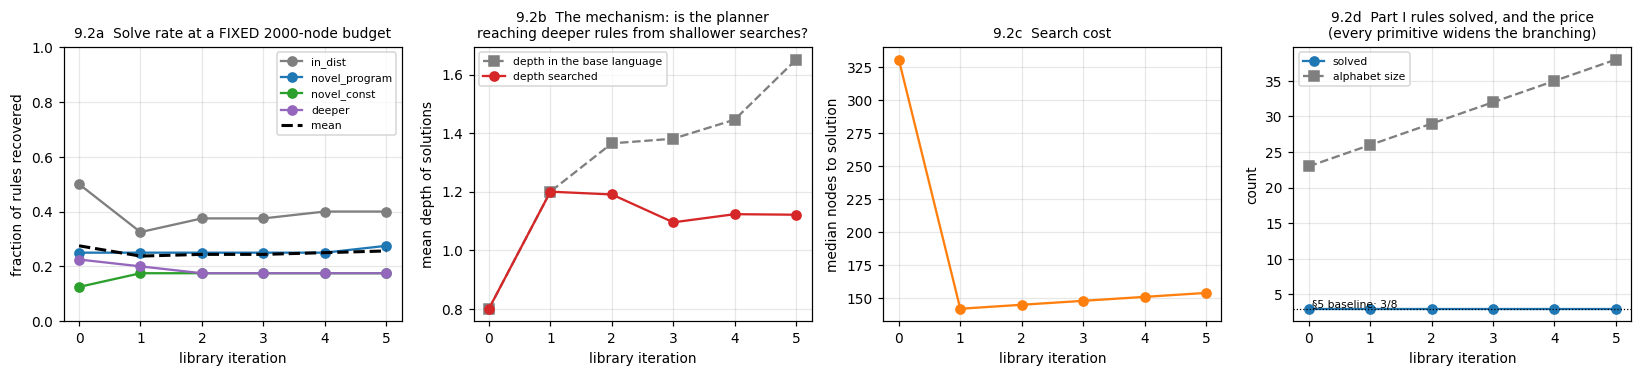


Part I rules, correct far-range by iteration (1 = solved):
tag              iter 0 (0 primitives)  iter 1 (3 primitives)  iter 2 (6 primitives)  iter 3 (9 primitives)  iter 4 (12 primitives)  iter 5 (15 primitives)
rule                                                                                                                                                       
(a mod 7)*b + 3                    0.0                    0.0                    0.0                    0.0                     0.0                     0.0
2a^2 + 16                          0.0                    0.0                    0.0                    0.0                     0.0                     0.0
4ab + 37                           0.0                    0.0                    0.0                    0.0                     0.0                     0.0
5*min(a,b) + 2                     0.0                    0.0                    0.0                    0.0                     0.0                     0.0
8a +

In [14]:
# ===================== 9.2  did abstraction buy depth? =======================
lg = pd.DataFrame(lib_rows)
by_axis = lg.groupby(["tag", "axis"])["correct"].mean().unstack()
TAGS = [f"iter {int(r.iter)} ({int(r.n_prims)} primitives)" for _, r in growth.iterrows()]
by_axis = by_axis.reindex(TAGS)
print("correct (held-out rules recovered) by library iteration and axis:")
print(by_axis.round(2).to_string())

fig, axes = plt.subplots(1, 4, figsize=(15, 3.5))
it = growth["iter"].values

ax = axes[0]
for a, c in zip(AXES, ["tab:gray", "tab:blue", "tab:green", "tab:purple"]):
    ax.plot(it, by_axis[a].values, "o-", color=c, label=a)
ax.plot(it, growth["correct"], "k--", lw=2, label="mean")
ax.set_xlabel("library iteration"); ax.set_ylabel("fraction of rules recovered")
ax.set_ylim(0, 1); ax.legend(fontsize=7)
ax.set_title("9.2a  Solve rate at a FIXED 2000-node budget", fontsize=9)

ax = axes[1]
ax.plot(it, growth["mean_depth_base"], "s--", color="tab:gray",
        label="depth in the base language")
ax.plot(it, growth["mean_depth"], "o-", color="tab:red", label="depth searched")
ax.set_xlabel("library iteration"); ax.set_ylabel("mean depth of solutions")
ax.legend(fontsize=7)
ax.set_title("9.2b  The mechanism: is the planner\nreaching deeper rules from shallower searches?",
             fontsize=9)

ax = axes[2]
ax.plot(it, growth["median_nodes"], "o-", color="tab:orange")
ax.set_xlabel("library iteration"); ax.set_ylabel("median nodes to solution")
ax.set_title("9.2c  Search cost", fontsize=9)

ax = axes[3]
ax.plot(it, growth["part_i"], "o-", color="tab:blue", label="solved")
ax.plot(it, growth["tokens"], "s--", color="tab:gray", label="alphabet size")
ax.axhline(3, color="k", ls=":", lw=.8)
ax.text(0.05, 3.15, "§5 baseline: 3/8", fontsize=7)
ax.set_xlabel("library iteration"); ax.set_ylabel("count")
ax.legend(fontsize=7)
ax.set_title("9.2d  Part I rules solved, and the price\n(every primitive widens the branching)",
             fontsize=9)
plt.tight_layout(); plt.show()

# --- which Part I rules flipped? --------------------------------------------
pi = pd.DataFrame(parti_rows)
flip = pi.pivot_table(index="rule", columns="tag", values="correct")
flip = flip[[c for c in TAGS if c in flip.columns]]
print("\nPart I rules, correct far-range by iteration (1 = solved):")
print(flip.round(0).to_string())

first, last = growth.iloc[0], growth.iloc[-1]
print(f"\nsummary: {first.n_prims} -> {last.n_prims} primitives, "
      f"alphabet {int(first.tokens)} -> {int(last.tokens)} tokens")
print(f"  held-out rules recovered : {first.correct:.2f} -> {last.correct:.2f}")
print(f"  depth searched           : {first.mean_depth:.2f} -> {last.mean_depth:.2f}")
print(f"  depth of the rules found : {first.mean_depth_base:.2f} -> {last.mean_depth_base:.2f}")
print(f"  median nodes to solution : {first.median_nodes:.0f} -> {last.median_nodes:.0f}")
print(f"  Part I rules solved      : {int(first.part_i)}/8 -> {int(last.part_i)}/8")

seeded: F1(x) = ((? * x) + ?), F2(x, y) = ((x * y) + ?)

Part I: baseline vs. grown library vs. hand-seeded library
           rule      kind  before  grown  seeded  nodes_seeded
(a mod 7)*b + 3  non-poly     0.0    0.0     0.0          2061
      2a^2 + 16     novel     0.0    0.0     1.0          1421
       4ab + 37     novel     0.0    0.0     1.0          1421
 5*min(a,b) + 2  non-poly     0.0    0.0     0.0          2061
   8a + 7b + 55     novel     0.0    0.0     0.0          2061
          a * b canonical     1.0    1.0     1.0           717
          a + b canonical     1.0    1.0     1.0           461
            a^2 canonical     1.0    1.0     1.0           717

  solved: 3/8 baseline -> 3/8 grown -> 5/8 with the two primitives handed over


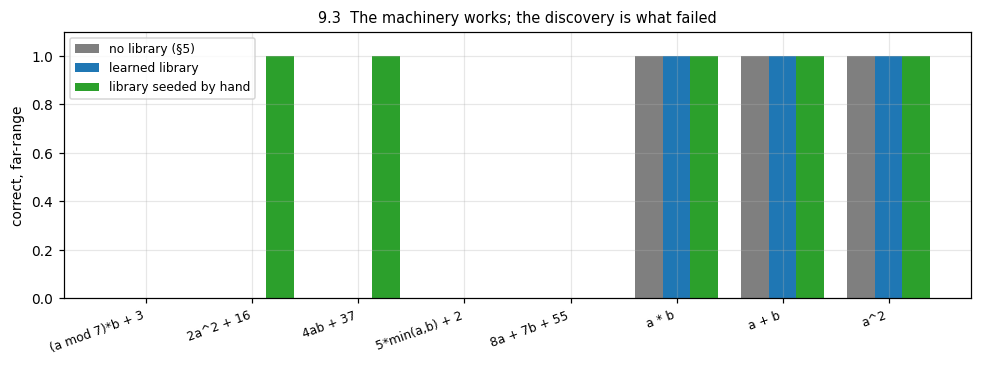


library restored to the 2 learned primitives


In [16]:
# ============ 9.3  is it the machinery or the discovery that failed? =========
# The Part I rules did not flip. There are two candidate explanations and they
# have different consequences: either the enlarged language cannot reach them
# (the machinery is wrong), or the abstraction step never proposed the primitive
# they need (the discovery is wrong). Seeding the library by hand separates them.
saved_lib = {k: dict(v) for k, v in LIB.items()}
LIB.clear(); refresh_tokens()          # base language + ONLY the two seeded primitives

ORACLE = [
    ("(? * x) + ?",   ("+", ("*", ("?",), ("arg", 0)), ("?",)), 1, 2),
    ("(x * y) + ?",   ("+", ("*", ("arg", 0), ("arg", 1)), ("?",)), 2, 1),
]
oracle_names = []
for desc, body, arity, nh in ORACLE:
    oracle_names.append(add_primitive(body, arity, nh))
print("seeded:", ", ".join(prim_str(n) for n in oracle_names))

seeded = eval_part_i(PCFGScorer(), f"oracle-seeded ({len(LIB)} primitives)")
base = [r for r in parti_rows if r["tag"] == TAGS[0]]
grown_map = {r["rule"]: r["correct"] for r in parti_rows if r["tag"] == TAGS[-1]}
cmp_rows = []
for b, s in zip(sorted(base, key=lambda r: r["rule"]), sorted(seeded, key=lambda r: r["rule"])):
    cmp_rows.append(dict(rule=b["rule"], kind=b["kind"], before=b["correct"],
                         grown=float(grown_map[b["rule"]]),
                         seeded=s["correct"], nodes_seeded=s["nodes"]))

cmp = pd.DataFrame(cmp_rows)
print("\nPart I: baseline vs. grown library vs. hand-seeded library")
print(cmp.to_string(index=False))
print(f"\n  solved: {int(cmp.before.sum())}/8 baseline -> {int(cmp.grown.sum())}/8 grown "
      f"-> {int(cmp.seeded.sum())}/8 with the two primitives handed over")

fig, ax = plt.subplots(figsize=(9, 3.4))
x = np.arange(len(cmp)); w = .26
for i, (col, lab, c) in enumerate([("before", "no library (§5)", "tab:gray"),
                                   ("grown", "learned library", "tab:blue"),
                                   ("seeded", "library seeded by hand", "tab:green")]):
    ax.bar(x + (i - 1) * w, cmp[col], width=w, color=c, label=lab)
ax.set_xticks(x); ax.set_xticklabels(cmp["rule"], rotation=20, ha="right", fontsize=8)
ax.set_ylabel("correct, far-range"); ax.set_ylim(0, 1.1); ax.legend(fontsize=8)
ax.set_title("9.3  The machinery works; the discovery is what failed", fontsize=9.5)
plt.tight_layout(); plt.show()

LIB.clear(); LIB.update(saved_lib); refresh_tokens()      # restore the learned library
print(f"\nlibrary restored to the {len(LIB)} learned primitives")

---
# 10. Reading the library experiment

## 10.1 The four pre-registered criteria

§8 committed to four predictions before the loop was run. Two held, two did not, and the two that
failed are the more informative half.

| criterion | prediction | result over 5 iterations, 0 → 15 primitives |
|---|---|---|
| 1. solve rate rises | yes | **no.** Rules *recovered* went 0.28 → 0.26, dipping to 0.24 |
| 2. nodes-to-solution falls | yes | **yes** — 331 → 154, a 2.1× reduction |
| 3. solutions get shallower | yes | **yes, in the two-curve form**: searched 0.80 → 1.12 while the rules found went 0.80 → **1.65** |
| 4. some Part I rules flip | yes | **no** — 3/8 at every iteration |

**Criterion 3 is the mechanism, and it is visible.** By iteration 5 the planner searches to a mean depth
of 1.12 and comes back with rules whose depth in the *base* language is 1.65, at less than half the node
cost. It is reaching further while descending less far, which is exactly what abstraction is supposed to
buy. Reporting a single "mean solution depth" would have shown a *rise* from 0.80 to 1.12 and made the
mechanism look refuted; the two curves separate the selection effect from the effect.

**Criterion 1 failed in a way worth dwelling on.** Look at the two columns together:

| iteration | 0 | 1 | 2 | 3 | 4 | 5 |
|---|---|---|---|---|---|---|
| **solved** (fits the 8 examples) | 0.34 | 0.38 | 0.39 | 0.39 | 0.41 | **0.41** |
| **correct** (is the true rule) | 0.28 | 0.24 | 0.24 | 0.24 | 0.25 | **0.26** |
| gap | 0.07 | 0.14 | 0.15 | 0.15 | 0.16 | **0.16** |

The library made the system a **better fitter and a slightly worse inducer**. Solve rate climbs
monotonically; the gap between fitting eight observations and recovering the rule more than doubles.
The reason is not mysterious: abstraction increases the density of *short* programs, and short programs
are what the search returns first, so every iteration adds more ways to explain eight data points
cheaply. Some of those are the rule and more of them are not.

This is the aliasing result from the first notebook arriving from a new direction. There, 386 training
points left a 638-dimensional space of hypotheses consistent with them; here, enlarging the language
enlarges the set of short hypotheses consistent with eight examples. **Compression and identification are
not the same objective, and optimising the first can degrade the second.** The practical implication is
concrete: a library-learning system needs either more examples per task or an explicit penalty on
description length at *selection* time, not only at abstraction time.

Per axis, the trade is legible: `in_dist` fell 0.50 → 0.40 while `novel_const` rose 0.12 → 0.18 and
`novel_program` 0.25 → 0.28. The library helps where the base language was weakest and hurts where it
was strongest — breadth costing more than depth saves, on exactly the tasks the base language already
handled.

## 10.2 The interesting failure, and what §9.3 proves about it

Not one of the five Part I rules flipped. §9.3 separates the two possible reasons by handing the system
two primitives — $(? \times x) + ?$ and $(x \times y) + ?$ — on top of the *base* language and re-running
the identical planner at the identical budget: **3/8 → 5/8**. $2a^2+16$ and $4ab+37$ are both found, in
~1400 nodes where 2000 had not been enough. The enlarged language reaches them comfortably. The
machinery is not the problem.

The direct evidence for what is sits in the printed library. Fifteen invented primitives, and here is
the whole vocabulary they are built from:

```
F1(x)    = (x // ?)          F2(x)    = (x + ?)           F3(x)    = (x - ?)
F4(x)    = ((x + ?) // ?)    F5(x,y)  = ((x + ?) % y)     F6(x,y)  = ((x // y) // ?)
F7(x,y)  = (((x + ?) % y) // ?)                           F8(x,y)  = (((x + ?) % y) + ?)
F9(x,y)  = (((x + ?) // y) // ?)                          F10(x,y) = (((x - y) + ?) // ?)
F11(x,y) = ((x // y) + ?)    F12(x,y) = ((x + ?) // y)    F13(x,y) = ((x - y) + ?)
F14(x,y) = ((x + y) - ?)     F15(x,y) = ((x + y) + ?)
```

**Not one of them contains a multiplication.** Every abstraction the system invented is a division,
modulo or additive idiom, because those are the shapes that recur in the programs it could already find:
best-first returns the *shortest* fitting program, and short fitting programs in this task distribution
are overwhelmingly `//` and `%` expressions. The primitive the Part I rules need, $(? \times x) + ?$,
never recurred three times in a corpus of 239 solutions, so it was never a candidate.

> **Library learning abstracts over the solutions you already have, so it cannot invent the abstraction
> you need in order to solve what you currently cannot.**

That is a structural limit, not a tuning accident, and it sharpens what "produces new knowledge" can
honestly mean for this system. It compresses its own competence and reaches modestly further on the next
iteration. It does not bootstrap across a gap.

## 10.3 What follows, in the order I would do it

1. **A curriculum is the missing mechanism, not an optional extra.** DreamCoder's growth curves come with
   task sets graded in difficulty, so the wake phase always has something just above its current reach.
   Here the wake set is drawn from the same distribution throughout, so the corpus of solutions — and
   therefore the library — never moves. Feed the wake phase tasks whose rules are one composition level
   deeper than the current library can reach and re-run §9. If multiplication idioms then appear and the
   Part I rules flip, the ceiling was curriculum. This is one changed line (`WAKE_TASKS`) and it is the
   highest-value experiment left in this notebook.
2. **Select on description length, not only compress on it.** The widening solved-correct gap in §10.1
   says the search now returns short-but-wrong programs more often. Ranking the *candidates that fit* by
   expanded-program length, or requiring agreement between the top two distinct fitting programs, should
   buy back identification without touching the library.
3. **Prune the library.** Nothing removes a primitive that has stopped paying, and the per-axis numbers
   suggest several never paid. Track per-primitive usage in the wake phase and drop the unused ones.
4. **Abstract from the true rules as a diagnostic upper bound.** Running the sleep phase on the
   generating programs rather than the found ones is not a legitimate system — it uses labels the learner
   should not have — but it would bound how much of §10.2's gap better discovery could close.
5. **Then the LLM proposer.** §6 priced the learned prior at +0.08 against the representation's +0.15.
   Library learning was the attempt to raise the second number and it moved search cost rather than
   accuracy. A stronger proposal distribution becomes worth its cost once the target rules are depth-2 in
   the language — which, per §9.3, requires getting the *right* abstractions first.